## Composite silhouette $S_{mM}$

In [ ]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans, MiniBatchKMeans, Birch, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_samples
from sklearn.utils import resample

import matplotlib.pyplot as plt
from joblib import Parallel, delayed


from sklearn.cluster import KMeans, MiniBatchKMeans, Birch, AgglomerativeClustering, BisectingKMeans
from sklearn.mixture import GaussianMixture

import numpy as np


def _kmedoids_clara_like_labels(
    X,
    k,
    seed,
    num_subsamples=5,
    subsample_size=2000,
    metric="euclidean",
    init="k-medoids++",
    max_iter=300,
):
    """
    CLARA-like K-Medoids:
      - draw several subsamples
      - fit KMedoids on each subsample
      - pick the medoids that minimize full-data inertia (sum of distances to closest medoid)
      - assign all points to nearest chosen medoid -> labels

    This is not the exact original CLARA implementation, but it's the same idea and works well in practice.
    """
    rng = np.random.RandomState(int(seed))
    X = np.asarray(X)
    n = X.shape[0]
    k = int(k)

    if k < 2 or k >= n:
        raise ValueError("k must be in [2, n-1]")

    # keep subsample reasonable
    m = int(min(max(k + 1, subsample_size), n))
    best_medoids = None
    best_inertia = np.inf

    # local import to avoid hard dependency if you want
    from sklearn.metrics import pairwise_distances

    for t in range(int(num_subsamples)):
        # subsample indices without replacement
        idx = rng.choice(n, size=m, replace=False)
        Xs = X[idx]

        model = KMedoids(
            n_clusters=k,
            metric=metric,
            init=init,
            max_iter=int(max_iter),
            random_state=int(seed) + t,
        )
        model.fit(Xs)

        medoids = model.cluster_centers_  # shape (k, d)

        # Evaluate on FULL data: distance to closest medoid
        D = pairwise_distances(X, medoids, metric=metric)
        inertia = float(np.sum(np.min(D, axis=1)))

        if inertia < best_inertia:
            best_inertia = inertia
            best_medoids = medoids

    # Final assignment using best medoids
    D = pairwise_distances(X, best_medoids, metric=metric)
    labels = np.argmin(D, axis=1)
    return labels

from sklearn.cluster import KMeans, MiniBatchKMeans, Birch, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture

def _fit_predict_labels(X, k, seed, algo="spectral", kmeans_n_init=1, mb_batch_size=1024,
                        spectral_affinity="nearest_neighbors", spectral_n_neighbors=10):
    algo = str(algo).lower()
    k = int(k)

    if algo == "kmeans":
        model = KMeans(n_clusters=k, random_state=int(seed), n_init=int(kmeans_n_init))
        return model.fit_predict(X)

    if algo in ("minibatchkmeans", "mbkmeans", "mbk"):
        model = MiniBatchKMeans(
            n_clusters=k,
            random_state=int(seed),
            n_init=int(kmeans_n_init),
            batch_size=int(mb_batch_size),
        )
        return model.fit_predict(X)

    if algo == "birch":
        model = Birch(n_clusters=k)
        return model.fit_predict(X)

    if algo in ("agglomerative", "agg"):
        model = AgglomerativeClustering(n_clusters=k, linkage="ward")
        return model.fit_predict(X)
    if algo in ("spectral", "spectralclustering"):
        model = SpectralClustering(
            n_clusters=k,
            random_state=int(seed),
            affinity=str(spectral_affinity),
            n_neighbors=int(spectral_n_neighbors),
            assign_labels="kmeans",
        )
        return model.fit_predict(X)

    if algo in ("gmm", "gaussianmixture"):
        model = GaussianMixture(
            n_components=k,
            random_state=int(seed),
            covariance_type="full",
            init_params="kmeans",
            n_init=1,
        )
        return model.fit_predict(X)

    raise ValueError(
        f"Unknown algo='{algo}'. Supported: kmeans, minibatchkmeans, birch, agglomerative, spectral, gmm."
    )

class CompSil:
    """
    Composite Silhouette (CompSil)

    Per subsample b=1..B for each k:
      - compute S_micro^(b), S_macro^(b)
      - Δ_b = S_micro^(b) - S_macro^(b)
      - D = max_b |Δ_b|
      - r_raw_b = Δ_b/(D+eps) in [-1,1]
      - r_b = tanh(r_raw_b)
      - w_b = (1+r_b)/2
      - S_mM^(b) = w_b*S_micro^(b) + (1-w_b)*S_macro^(b)

    Aggregate for each k:
      - mean score:   S_mM(k)  = mean_b S_mM^(b)
      - std score:    std_S_mM(k) = std_b  S_mM^(b)
      - standard error: se_S_mM(k) = std_S_mM(k) / sqrt(B_eff)
      - lower conf bound: LCB_S_mM(k) = S_mM(k) - se_S_mM(k)

    Selection:
      - k* = argmax_k S_mM(k) (or argmax_k LCB_S_mM(k))

    Sampling size mechanism:
      - explicit `sample_size` (int), or
      - sample_size=None or sample_size="auto", the class chooses a subsample size automatically
        based on dataset size N and the maximum k in `k_values`.

    Parameters:
    - data: ndarray or DataFrame, shape (n_samples, n_features)
    - ground_truth: int, optional
    - k_values: iterable or int, default=range(2, 11)
    - num_samples: int, default=100  (B)
    - sample_size: int | float | None | "auto", default=1000
        * int: absolute subsample size m
        * float in (0,1]: treated as fraction f, m = floor(f*N)
        * None or "auto": compute m automatically (see _auto_sample_size)
    - random_state: int, default=42
    - n_jobs: int, default=-1
    - eps: float, default=1e-12
    - algo: str, default="kmeans"
        one of {"kmeans","minibatchkmeans","birch","agglomerative","gmm"}
    - kmeans_n_init: int, default=1
        used for kmeans / minibatchkmeans
    - mb_batch_size: int, default=1024
        used for minibatchkmeans
    """

    def __init__(self,
                 data,
                 ground_truth=None,
                 k_values=range(2, 11),
                 num_samples=10,
                 sample_size="auto",
                 random_state=42,
                 n_jobs=-1,
                 eps=1e-12,
                 algo="spectral",
                 kmeans_n_init=1,
                 mb_batch_size=1024):
        self.data = data
        self.ground_truth = ground_truth
        self.k_values = [k_values] if isinstance(k_values, int) else list(k_values)
        self.num_samples = int(num_samples)
        self.random_state = int(random_state)
        self.n_jobs = int(n_jobs)
        self.eps = float(eps)

        self.algo = str(algo).lower()
        self.kmeans_n_init = int(kmeans_n_init)
        self.mb_batch_size = int(mb_batch_size)

        self._results = []
        self.results_df = pd.DataFrame()
        self.score_ = None  # set only if one k is evaluated

        self.n_samples_ = int(len(self.data))
        if self.n_samples_ <= 0:
            raise ValueError("Empty dataset.")

        self.sample_size = self._resolve_sample_size(sample_size)
        self.sample_fraction_ = self.sample_size / self.n_samples_

        if self.sample_size < 2:
            raise ValueError(f"Resolved sample_size={self.sample_size} is too small.")
        if self.sample_size > self.n_samples_:
            raise ValueError(
                f"Resolved sample_size={self.sample_size} is larger than n_samples={self.n_samples_}."
            )

    def _resolve_sample_size(self, sample_size):
        n = self.n_samples_

        # Auto
        if sample_size is None or (isinstance(sample_size, str) and sample_size.lower() == "auto"):
            return self._auto_sample_size()

        # Fraction mode (float in (0,1])
        if isinstance(sample_size, float):
            if not (0.0 < sample_size <= 1.0):
                raise ValueError("If sample_size is a float, it must be in (0, 1].")
            m = int(np.floor(sample_size * n))
            return max(2, min(m, n))

        # Int mode
        m = int(sample_size)
        return m

    def _auto_sample_size(self):
        """
        Automatic subsample size selection (no user-facing hyperparameters).

        Heuristic:
          1) Ensure a minimum average points-per-cluster at k_max: m >= 30 * k_max
          2) Use a baseline fraction depending on dataset size:
             - small N: 0.8N
             - medium N: 0.6N
             - large N: 0.4N
          3) Take the maximum of (1) and (2), then cap at N.
        """
        n = self.n_samples_
        k_max = int(max(self.k_values)) if len(self.k_values) > 0 else 2

        m_min = 30 * k_max

        if n <= 2000:
            m_base = int(np.floor(0.80 * n))
        elif n <= 20000:
            m_base = int(np.floor(0.60 * n))
        else:
            m_base = int(np.floor(0.40 * n))

        m = max(m_min, m_base)
        m = min(max(2, m), n)
        return m

    def evaluate_sample(self, k, i):
        """
        One subsampling iteration for fixed k.
        Returns: (smicro, smacro, diff, s_mm_b)
        """
        seed = self.random_state + i

        sampled_data = resample(
            self.data,
            n_samples=self.sample_size,
            replace=False,
            random_state=seed
        )

        labels = _fit_predict_labels(
            sampled_data,
            k=int(k),
            seed=int(seed),
            algo=self.algo,
            kmeans_n_init=self.kmeans_n_init,
            mb_batch_size=self.mb_batch_size,
        )

        try:
            s = silhouette_samples(sampled_data, labels)  # compute once

            # micro silhouette
            smicro = float(np.mean(s))

            labs = np.asarray(labels)
            uniq = np.unique(labs)
            cluster_means = [float(np.mean(s[labs == u])) for u in uniq]

            # macro silhouette
            smacro = float(np.mean(cluster_means)) if len(cluster_means) > 0 else np.nan
        except Exception:
            return np.nan, np.nan, np.nan, np.nan

        diff = smicro - smacro
        return smicro, smacro, diff, np.nan

    @staticmethod
    def _tanh_rb_weights_from_differences(differences, eps=1e-12):
        """
        Given Δ_b over b=1..B, compute:
          D       = max |Δ_b|
          r_raw_b = Δ_b/(D+eps) in [-1, 1]
          r_b     = tanh(r_raw_b)
          w_b     = (1+r_b)/2 in (0,1)
        """
        d = np.asarray(differences, dtype=float)
        finite = np.isfinite(d)

        if not np.any(finite):
            return d * np.nan, d * np.nan, np.nan

        D = float(np.max(np.abs(d[finite])))
        denom = D + float(eps)

        if D == 0.0:
            r = np.zeros_like(d)
            r[~finite] = np.nan
            w = 0.5 * np.ones_like(d)
            w[~finite] = np.nan
            return w, r, D

        r_raw = d / denom
        r_raw = np.clip(r_raw, -1.0, 1.0)
        r_raw[~finite] = np.nan

        r = np.tanh(r_raw)
        r[~finite] = np.nan

        w = 0.5 * (1.0 + r)
        w[~finite] = np.nan

        return w, r, D

    def evaluate(self):
        """
        Evaluate over k_values using subsampled clustering.
        Stores results in self.results_df.

        Output columns (per k):
        - avg S_micro
        - avg S_macro
        - w_micro (mean of per-subsample weights; descriptive)
        - S_mM (mean of per-subsample composites)
        - std S_mM
        - se S_mM
        - LCB S_mM  (S_mM - se)
        """
        self._results = []

        for k in self.k_values:
            results = Parallel(n_jobs=self.n_jobs)(
                delayed(self.evaluate_sample)(k, i) for i in range(self.num_samples)
            )

            smicro_list, smacro_list, differences, _ = zip(*results)

            smicro_arr = np.asarray(smicro_list, dtype=float)
            smacro_arr = np.asarray(smacro_list, dtype=float)
            diff_arr = np.asarray(differences, dtype=float)

            avg_smicro = float(np.nanmean(smicro_arr)) if np.any(np.isfinite(smicro_arr)) else np.nan
            avg_smacro = float(np.nanmean(smacro_arr)) if np.any(np.isfinite(smacro_arr)) else np.nan

            # weights
            w_b, r_b, D = self._tanh_rb_weights_from_differences(diff_arr, eps=self.eps)

            # per-subsample composite
            S_b = w_b * smicro_arr + (1.0 - w_b) * smacro_arr

            # mean composite
            S_mM = float(np.nanmean(S_b)) if np.any(np.isfinite(S_b)) else np.nan

            # descriptive mean weight
            w_micro_mean = float(np.nanmean(w_b)) if np.any(np.isfinite(w_b)) else np.nan

            # LCB components computed from S_b across valid subsamples
            finite_sb = np.isfinite(S_b)
            B_eff = int(np.sum(finite_sb))
            if B_eff >= 2:
                std_smm = float(np.nanstd(S_b, ddof=1))
                se_smm = std_smm / np.sqrt(B_eff)
            elif B_eff == 1:
                std_smm = 0.0
                se_smm = 0.0
            else:
                std_smm = np.nan
                se_smm = np.nan

            lcb_smm = (S_mM - se_smm) if (np.isfinite(S_mM) and np.isfinite(se_smm)) else np.nan

            if len(self.k_values) == 1:
                self.score_ = S_mM

            result = {
                'k': int(k),
                'avg S_micro': avg_smicro,
                'avg S_macro': avg_smacro,
                'w_micro': w_micro_mean,
                'S_mM': S_mM,
                'std S_mM': std_smm,
                'se S_mM': se_smm,
                'LCB S_mM': lcb_smm,
                'B_eff': B_eff,
                'sample_size': int(self.sample_size),
                'sample_fraction': float(self.sample_fraction_),
            }
            self._results.append(result)

        self.results_df = pd.DataFrame(self._results)

    def plot_results(self):
        """
        Plot S_mM and individual averages vs k.
        """
        if self.results_df.empty:
            raise ValueError("No results available. Run evaluate() first.")
        if len(self.results_df) == 1:
            raise ValueError("Cannot plot with only one k. Evaluate multiple k values.")

        max_smicro = self.results_df['avg S_micro'].max()
        max_smicro_k = self.results_df.loc[self.results_df['avg S_micro'].idxmax(), 'k']

        max_smacro = self.results_df['avg S_macro'].max()
        max_smacro_k = self.results_df.loc[self.results_df['avg S_macro'].idxmax(), 'k']

        max_smm = self.results_df['S_mM'].max()
        max_smm_k = self.results_df.loc[self.results_df['S_mM'].idxmax(), 'k']

        plt.figure(figsize=(10, 4))

        if self.ground_truth is not None:
            plt.axvline(
                x=self.ground_truth, color='red', linestyle='--', linewidth=2.5,
                label='Ground Truth'
            )

        plt.plot(
            self.results_df['k'], self.results_df['avg S_micro'],
            marker='o', linestyle='-', color='orange', linewidth=4, markersize=8, label='avg S_micro'
        )
        plt.plot(max_smicro_k, max_smicro, marker='*', color='orange', markersize=18)

        plt.plot(
            self.results_df['k'], self.results_df['avg S_macro'],
            marker='o', linestyle='-', color='blue', linewidth=4, markersize=8, label='avg S_macro'
        )
        plt.plot(max_smacro_k, max_smacro, marker='*', color='blue', markersize=18)

        plt.plot(
            self.results_df['k'], self.results_df['S_mM'],
            marker='o', linestyle='--', color='green', linewidth=4, markersize=8, label='S_mM'
        )
        plt.plot(max_smm_k, max_smm, marker='*', color='green', markersize=18)

        plt.xlabel('k', fontsize=15)
        plt.xticks(self.k_values, fontsize=14)
        plt.yticks(fontsize=14)
        plt.tick_params(axis='y', which='both', length=0)
        plt.grid(axis='y', linestyle='--')

        ax = plt.gca()
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['top'].set_visible(False)

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles, labels,
            loc="lower left",
            bbox_to_anchor=(0, 1.02, 1, 0.2),
            mode="expand",
            ncol=len(labels),
            frameon=False,
            fontsize=12
        )

        plt.tight_layout()
        plt.show()

    def get_optimal_k(self, use_lcb=False):
        """
        Return optimal k.

        By default, uses max selection:
          k* = argmax_k (S_mM) (use_lcb for argmax_k (LCB S_mM) selection)

        """
        if self.results_df.empty:
            raise ValueError("No results available. Run evaluate() first.")

        if len(self.results_df) == 1:
            return int(self.results_df['k'].iloc[0])

        col = 'LCB S_mM' if use_lcb else 'S_mM'
        if col not in self.results_df.columns:
            raise ValueError(f"Missing column '{col}'. Run evaluate() first.")

        optimal_row = self.results_df.loc[self.results_df[col].idxmax()]
        return int(optimal_row['k'])

    def get_results_dataframe(self):
        """
        Return results DataFrame indexed by k.
        """
        if self.results_df.empty:
            raise ValueError("No results available. Run evaluate() first.")
        return self.results_df.set_index('k', inplace=False)

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans, MiniBatchKMeans, Birch, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    davies_bouldin_score,
)

def argmax_k_and_value_at_gt(df, col, k_true):
    """
    Returns:
      k_hat : the k where df[col] is maximized
      v_gt  : df[col] evaluated at k_true (ground-truth k)
    Works whether k is a column or the index.
    """
    # k_hat
    idx = df[col].idxmax()
    if "k" in df.columns:
        k_hat = int(df.loc[idx, "k"])
    else:
        k_hat = int(idx)

    # v at ground-truth k
    k_true = int(k_true)
    if "k" in df.columns:
        s = df.loc[df["k"] == k_true, col]
        v_gt = float(s.iloc[0]) if len(s) else np.nan
    else:
        v_gt = float(df.loc[k_true, col]) if k_true in df.index else np.nan

    return k_hat, v_gt


def _silhouette_macro(X, labels):
    """Macro silhouette = mean over clusters of (cluster mean silhouette)."""
    s = silhouette_samples(X, labels)
    labs = np.asarray(labels)
    uniq = np.unique(labs)

    means = []
    for u in uniq:
        m = (labs == u)
        if np.any(m):
            means.append(float(np.mean(s[m])))

    return float(np.mean(means)) if means else np.nan


def mean_metrics_over_runs_choose_k(
    X,
    num_runs,
    k_values=range(2, 11),
    random_state=42,
    kmeans_n_init=1,
    k_true=None,
    algo="spectral",
    mb_batch_size=1024,
):
    """
    Full-data repeated KMeans runs to estimate k by mean internal indices.

    For each k in k_values:
      - run clustering num_runs times on full X (seed = random_state + run_id)
      - compute micro silhouette, macro silhouette, CH, DB
      - take mean across runs for each metric

    Select k by:
      - micro: argmax mean micro silhouette
      - macro: argmax mean macro silhouette
      - CH:    argmax mean CH
      - DB:    argmin mean DB

    RETURNS
      - k_micro/k_macro/k_ch/k_db: the selected k's
      - mean_*_at_k_* values are returned AT k_true (ground-truth k), not at the selected k

    If k_true is None, it falls back to values at selected k.
    """
    X_arr = np.asarray(X)
    n = int(X_arr.shape[0])

    k_list = [k_values] if isinstance(k_values, int) else list(k_values)
    if len(k_list) == 0:
        raise ValueError("k_values must contain at least one value.")
    if int(num_runs) < 1:
        raise ValueError("num_runs must be >= 1.")

    rows = []
    for k in k_list:
        k = int(k)
        if k < 2 or k >= n:
            rows.append({
                "k": k,
                "mean_micro": np.nan,
                "mean_macro": np.nan,
                "mean_ch": np.nan,
                "mean_db": np.nan,
                "runs_used": 0,
            })
            continue

        micro_vals, macro_vals, ch_vals, db_vals = [], [], [], []

        for i in range(int(num_runs)):
            seed = int(random_state) + i

            labels = _fit_predict_labels(
                X_arr,
                k=int(k),
                seed=int(seed),
                algo=algo,
                kmeans_n_init=int(kmeans_n_init),
                mb_batch_size=int(mb_batch_size),
            )

            try:
                micro_vals.append(float(silhouette_score(X_arr, labels)))
            except Exception:
                micro_vals.append(np.nan)

            try:
                macro_vals.append(float(_silhouette_macro(X_arr, labels)))
            except Exception:
                macro_vals.append(np.nan)

            try:
                ch_vals.append(float(calinski_harabasz_score(X_arr, labels)))
            except Exception:
                ch_vals.append(np.nan)

            try:
                db_vals.append(float(davies_bouldin_score(X_arr, labels)))
            except Exception:
                db_vals.append(np.nan)

        micro_vals = np.asarray(micro_vals, dtype=float)
        macro_vals = np.asarray(macro_vals, dtype=float)
        ch_vals = np.asarray(ch_vals, dtype=float)
        db_vals = np.asarray(db_vals, dtype=float)

        rows.append({
            "k": k,
            "mean_micro": float(np.nanmean(micro_vals)) if np.any(np.isfinite(micro_vals)) else np.nan,
            "mean_macro": float(np.nanmean(macro_vals)) if np.any(np.isfinite(macro_vals)) else np.nan,
            "mean_ch": float(np.nanmean(ch_vals)) if np.any(np.isfinite(ch_vals)) else np.nan,
            "mean_db": float(np.nanmean(db_vals)) if np.any(np.isfinite(db_vals)) else np.nan,
            "runs_used": int(num_runs),
        })

    means_df = pd.DataFrame(rows)

    def _pick_max(col):
        v = means_df[col].to_numpy(dtype=float)
        if not np.any(np.isfinite(v)):
            return np.nan, np.nan
        idx = int(np.nanargmax(v))
        return int(means_df.loc[idx, "k"]), float(means_df.loc[idx, col])

    def _pick_min(col):
        v = means_df[col].to_numpy(dtype=float)
        if not np.any(np.isfinite(v)):
            return np.nan, np.nan
        idx = int(np.nanargmin(v))
        return int(means_df.loc[idx, "k"]), float(means_df.loc[idx, col])

    # Selected k's
    k_micro, v_micro_sel = _pick_max("mean_micro")
    k_macro, v_macro_sel = _pick_max("mean_macro")
    k_ch,    v_ch_sel    = _pick_max("mean_ch")
    k_db,    v_db_sel    = _pick_min("mean_db")

    def _value_at_k(col, k_target):
        if k_target is None:
            return np.nan
        s = means_df.loc[means_df["k"] == int(k_target), col]
        return float(s.iloc[0]) if len(s) else np.nan

    if k_true is None:
        v_micro_out = v_micro_sel
        v_macro_out = v_macro_sel
        v_ch_out = v_ch_sel
        v_db_out = v_db_sel
    else:
        v_micro_out = _value_at_k("mean_micro", k_true)
        v_macro_out = _value_at_k("mean_macro", k_true)
        v_ch_out    = _value_at_k("mean_ch",    k_true)
        v_db_out    = _value_at_k("mean_db",    k_true)

    return {
        "k_micro": k_micro,
        "mean_micro_at_k_micro": v_micro_out,
        "k_macro": k_macro,
        "mean_macro_at_k_macro": v_macro_out,
        "k_ch": k_ch,
        "mean_ch_at_k_ch": v_ch_out,
        "k_db": k_db,
        "mean_db_at_k_db": v_db_out,
        "means_df": means_df,
    }

## Data

##### imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import (
    fetch_openml,
    fetch_20newsgroups,
    load_iris,
    load_wine,
    load_digits,
    load_breast_cancer,
    make_blobs,
)

from sklearn.preprocessing import StandardScaler, LabelEncoder, normalize, Normalizer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA, TruncatedSVD

from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras.datasets import cifar10, fashion_mnist

!pip install -q ucimlrepo

from ucimlrepo import fetch_ucirepo

import seaborn as sns
from torchvision.datasets import STL10
from torchvision import transforms, models
import torch

import numpy as np
from datasets import load_dataset
from sentence_transformers import SentenceTransformer

### Synthetic Datasets

In [ ]:
# Synthetic 1
data_1, true_labels_1 = make_blobs(n_samples=10000, centers=5, cluster_std=0.5, random_state=100)
scaler = StandardScaler()

s1 = scaler.fit_transform(data_1)
name_s1 = "S1"
k_s1 = 5

# Synthetic 2
data_2, true_labels_2 = make_blobs(n_samples=10000, centers=6, cluster_std=0.9, random_state=20)
scaler = StandardScaler()

s2 = scaler.fit_transform(data_2)
name_s2 = "S2"
k_s2 = 6

# Synthetic 3
cluster_sizes_3 = [1000, 1000, 100, 100, 100]  # 2 large, 3 small
centers_3 = [
    (0, 0),   # large cluster #1
    (3, 3),   # large cluster #2 (not too far from #1, so they merge in small k)
    (12, 12), # small cluster #1
    (-12, 12),# small cluster #2
    (0, 15),  # small cluster #3
]
stds = [1.8, 1.8, 0.5, 0.5, 0.5]  # bigger std for large clusters, smaller for small

X_3, y_3 = make_blobs(
    n_samples=cluster_sizes_3,
    centers=centers_3,
    cluster_std=stds,
    random_state=42
)

scaler = StandardScaler()

s3 = scaler.fit_transform(X_3)
name_s3 = "S3"
k_s3 = 5

# Synthetic 4
cluster_sizes_4 = [1500, 1500, 300, 300] + [80]*5 + [30]*3
# 4 (big+medium) + 5 small + 3 tiny = 12 clusters

centers_4 = [
    # Large clusters near each other
    (0, 0),        # Large #1
    (3, 3),        # Large #2

    # Medium clusters
    (8, 0),        # Medium #1
    (0, 8),        # Medium #2

    # 5 small clusters
    (18, 18),
    (-18, 18),
    (18, -18),
    (-18, -18),
    (22, 0),

    # 3 tiny clusters placed very far away
    (0, 25),
    (25, 25),
    (25, -25)
]

# Standard deviations
# - Large clusters bigger spread
# - Medium smaller
# - Small even smaller
# - Tiny very small spread
stds_4 = [
    2.2, 2.2,   # large
    1.2, 1.2,   # medium
    0.9, 0.9, 0.9, 0.9, 0.9,  # 5 small
    0.6, 0.6, 0.6             # 3 tiny
]

X_4, y_4 = make_blobs(
    n_samples=cluster_sizes_4,
    centers=centers_4,
    cluster_std=stds_4,
    random_state=47
)

scaler = StandardScaler()

s4 = scaler.fit_transform(X_4)
name_s4 = "S4"
k_s4 = 12

In [ ]:
synthetic_datasets = {
    name_s1: (s1, k_s1),
    name_s2: (s2, k_s2),
    name_s3: (s3, k_s3),
    name_s4: (s4, k_s4)
}

print(list(synthetic_datasets.keys()))

['S1', 'S2', 'S3', 'S4']


#### Visualization

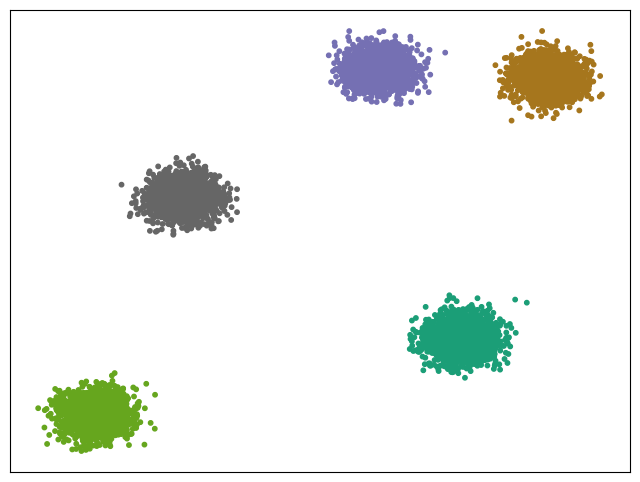

In [ ]:
# S1
plt.figure(figsize=(8,6))
plt.scatter(s1[:, 0], s1[:, 1], c=true_labels_1, cmap='Dark2', s=10)
plt.xticks([])
plt.yticks([])
plt.show()

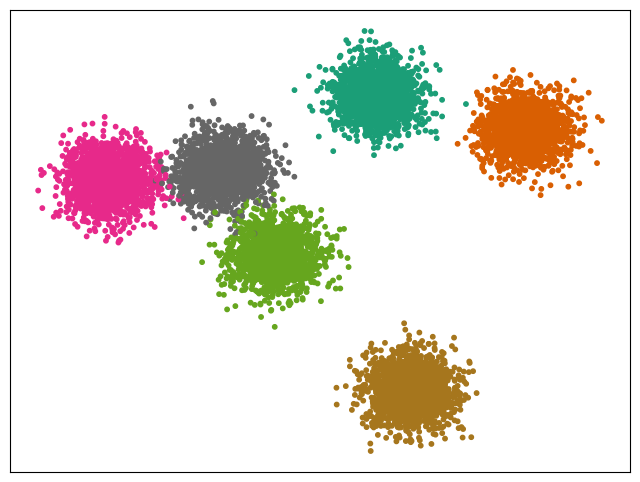

In [ ]:
# S2
plt.figure(figsize=(8,6))
plt.scatter(s2[:, 0], s2[:, 1], c=true_labels_2, cmap='Dark2', s=10)
plt.xticks([])
plt.yticks([])
plt.show()

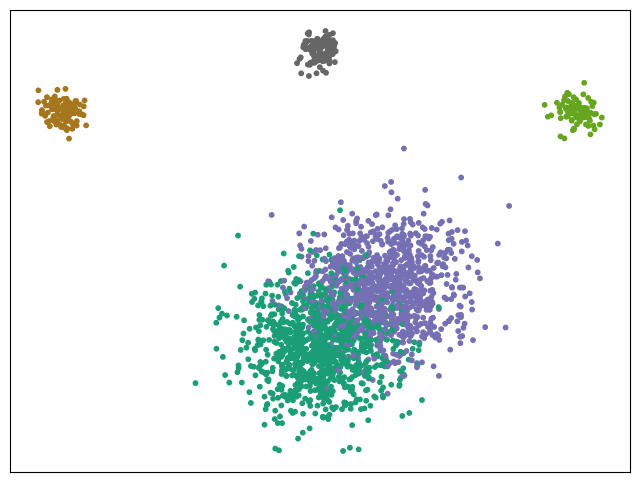

In [ ]:
# S3
plt.figure(figsize=(8,6))
plt.scatter(s3[:, 0], s3[:, 1], c=y_3, cmap='Dark2', s=10)
plt.xticks([])
plt.yticks([])
plt.show()

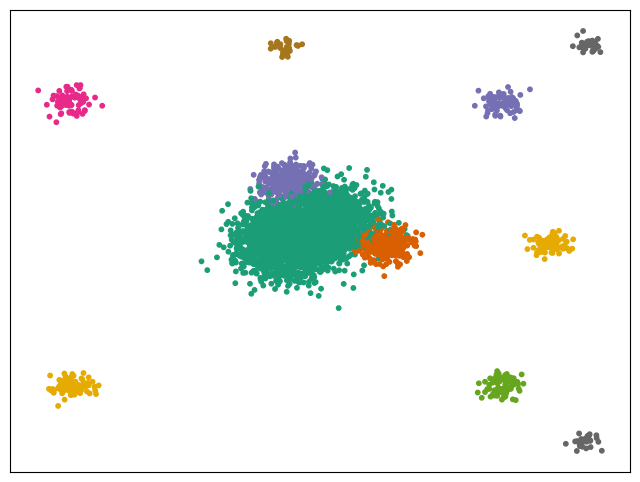

In [ ]:
# S4
plt.figure(figsize=(8,6))
plt.scatter(s4[:, 0], s4[:, 1], c=y_4, s=10, cmap='Dark2')
plt.xticks([])
plt.yticks([])
plt.show()

### Real datasets

In [ ]:
# Parkinsons
data_parkinson = fetch_openml(name='parkinsons', version=1, as_frame=True)
X_parkinson = data_parkinson.data
y_parkinson_raw = data_parkinson.target

le_parkinson = LabelEncoder()
y_parkinson = le_parkinson.fit_transform(y_parkinson_raw)
num_classes_parkinson = len(np.unique(y_parkinson))

X_park = StandardScaler().fit_transform(X_parkinson)
name_park = "Pks"
k_park = num_classes_parkinson

# Blood Transfusion
data_blood = fetch_openml(name='blood-transfusion-service-center', version=1, as_frame=True)
X_blood = data_blood.data
y_blood_raw = data_blood.target

le = LabelEncoder()
y_blood = le.fit_transform(y_blood_raw)
num_classes_blood = len(np.unique(y_blood))

X_blood_scaled = StandardScaler().fit_transform(X_blood)

X_blood = X_blood_scaled
name_blood = "Bld"
k_blood = num_classes_blood

# HTRU2
htru2 = fetch_ucirepo(id=372)
X_htru2 = htru2.data.features.to_numpy()
y_raw_htru2 = htru2.data.targets.iloc[:, 0]  # Single binary column

le_htru2 = LabelEncoder()
y_htru2 = le_htru2.fit_transform(y_raw_htru2)
num_classes_htru2 = len(np.unique(y_htru2))

X_htr= StandardScaler().fit_transform(X_htru2)
name_htr = "htr"
k_htr = num_classes_htru2

# Spambase
data_spambase = fetch_openml(name='spambase', version=1, as_frame=True)
X_spambase = data_spambase.data
y_spambase_raw = data_spambase.target

le_spam = LabelEncoder()
y_spambase = le_spam.fit_transform(y_spambase_raw)
num_classes_spambase = len(np.unique(y_spambase))

X_spam = StandardScaler().fit_transform(X_spambase)
name_spam = "Spm"
k_spam = num_classes_spambase

# Bank Marketing
data_bank = fetch_openml(name='bank-marketing', version=1, as_frame=True)
X_bank = data_bank.data.select_dtypes(include=[np.number])  # numeric features only
y_bank_raw = data_bank.target

le_bank = LabelEncoder()
y_bank = le_bank.fit_transform(y_bank_raw)
num_classes_bank = len(np.unique(y_bank))

X_bank = StandardScaler().fit_transform(X_bank)
name_bank = "Bnk"
k_bank = num_classes_bank

# Wine
data_wine = load_wine()
X_wine = data_wine.data
y_wine = data_wine.target

scaler = StandardScaler()

X_wine = scaler.fit_transform(X_wine)
name_wine = "Wne"
k_wine = len(set(y_wine))

# Digits
data_digits = load_digits()
X_digits = data_digits.data

pca = PCA(n_components=0.999)
X_digits = pca.fit_transform(X_digits)
name_digits = "Dgt"
k_digits = 10

# 20 Newsgroups
data_20ng = fetch_20newsgroups(subset='train')
num_classes_20ng = 20

vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = vectorizer.fit_transform(data_20ng.data)

svd = TruncatedSVD(n_components=50, random_state=0)
X_svd = svd.fit_transform(X_tfidf)

X_ng = X_svd
name_ng = "Nsg"
k_ng = num_classes_20ng

# STL-10
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = torch.nn.Identity()  # remove classification head
model.eval()

transform = transforms.Compose([
    transforms.Resize(96),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

dataset = STL10(root='data', split='train', download=True, transform=transform)

features, labels = [], []
with torch.no_grad():
    for img, label in dataset:
        f = model(img.unsqueeze(0)).squeeze().numpy()
        features.append(f)
        labels.append(label)

X_stl = np.array(features)
y_stl = np.array(labels)
num_classes_stl = len(np.unique(y_stl))

X_stl_scaled = StandardScaler().fit_transform(X_stl)

X_stl = X_stl_scaled
name_stl = "Stl"
k_stl = num_classes_stl

# BBC
bbc_ds = load_dataset("SetFit/bbc-news")
train_ds_bbc = bbc_ds["train"]
test_ds_bbc  = bbc_ds["test"]

texts_bbc = list(train_ds_bbc["text"]) + list(test_ds_bbc["text"])
labels_raw_bbc = list(train_ds_bbc["label"]) + list(test_ds_bbc["label"])
label_texts_bbc = list(train_ds_bbc["label_text"]) + list(test_ds_bbc["label_text"])

y_bbc = np.array(labels_raw_bbc, dtype=int)
k_bbc = len(np.unique(y_bbc))

label_map = {}
for lab, lab_txt in zip(labels_raw_bbc, label_texts_bbc):
    lab = int(lab)
    if lab not in label_map:
        label_map[lab] = lab_txt

model = SentenceTransformer("all-MiniLM-L6-v2")
X_embed_bbc = model.encode(
    texts_bbc,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
)

pca = PCA(n_components=50, random_state=0)
X_bbc_embed_50 = pca.fit_transform(X_embed_bbc)

X_bbc = X_bbc_embed_50
name_bbc = "Bbc"
k_bbc = len(np.unique(y_bbc))

# Minds-14
encoder_minilm = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def build_minilm_pca_features(
    texts,
    n_components=50,
    encoder=encoder_minilm,
    random_state=0,
):
    """
    texts -> MiniLM embeddings -> PCA(n_components) -> L2-normalized
    """
    X_emb = encoder.encode(
        list(map(str, texts)),
        convert_to_numpy=True,
        show_progress_bar=True
    ).astype(np.float64)

    pca = PCA(
        n_components=n_components,
        whiten=False,
        random_state=random_state
    )
    X_pca = pca.fit_transform(X_emb)

    normalizer = Normalizer(norm="l2", copy=False)
    X_final = normalizer.fit_transform(X_pca)

    return X_final, pca, normalizer

ds_minds_train = load_dataset("DeepPavlov/minds14", split="train")
ds_minds_test  = load_dataset("DeepPavlov/minds14", split="test")

texts_minds = (
    list(map(str, ds_minds_train["utterance"])) +
    list(map(str, ds_minds_test["utterance"]))
)
labels_minds_raw = (
    list(ds_minds_train["label"]) +
    list(ds_minds_test["label"])
)

le_minds = LabelEncoder()
y_minds = le_minds.fit_transform(labels_minds_raw)
k_minds = len(np.unique(y_minds))

X_minds_minilm, pca_minds, norm_minds_emb = build_minilm_pca_features(
    texts_minds,
    n_components=85,
    encoder=encoder_minilm,
    random_state=0,
)

X_minds = X_minds_minilm
name_minds = "Mds"
k_minds = len(np.unique(y_minds))

# Banking 77
ds_train = load_dataset("PolyAI/banking77", split="train", revision="refs/convert/parquet")
ds_test  = load_dataset("PolyAI/banking77", split="test",  revision="refs/convert/parquet")

texts_b77 = list(map(str, ds_train["text"])) + list(map(str, ds_test["text"]))
labels_b77_raw = list(ds_train["label"]) + list(ds_test["label"])

le = LabelEncoder()
y_b77 = le.fit_transform(labels_b77_raw)

k_b77 = len(np.unique(y_b77))

encoder_b77 = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
X_b77_embed = encoder_b77.encode(
    texts_b77,
    convert_to_numpy=True,
    show_progress_bar=False
).astype(np.float64)

pca_b77 = PCA(
    n_components=50,
    whiten=False,
    random_state=0
)
X_b77_pca = pca_b77.fit_transform(X_b77_embed)

normalizer = Normalizer(norm="l2", copy=False)
X_b77 = normalizer.fit_transform(X_b77_pca)

pca_b77 = PCA(
    n_components=50,
    whiten=False,
    random_state=0
)

X_b77_pca = pca_b77.fit_transform(X_b77_embed)

normalizer = Normalizer(norm="l2", copy=False)

X_b77 = normalizer.fit_transform(X_b77_pca)
name_b77 = "B77"
k_b77 = len(np.unique(y_b77))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]
100%|██████████| 2.64G/2.64G [04:18<00:00, 10.2MB/s]


README.md:   0%|          | 0.00/880 [00:00<?, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

...

0000.parquet:   0%|          | 0.00/93.9k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
real_datasets = {
    name_park: (X_park, k_park),
    name_blood: (X_blood, k_blood),
    name_htr: (X_htr, k_htr),
    name_spam: (X_spam, k_spam),
    name_bank: (X_bank, k_bank),
    name_wine: (X_wine, k_wine),
    name_digits: (X_digits, k_digits),
    name_ng: (X_ng, k_ng),
    name_stl: (X_stl, k_stl),
    name_bbc: (X_bbc, k_bbc),
    name_minds: (X_minds, k_minds),
    name_b77: (X_b77, k_b77)
}

print(list(real_datasets.keys()))

['Pks', 'Bld', 'htr', 'Spm', 'Bnk', 'Wne', 'Dgt', 'Nsg', 'Stl', 'Bbc', 'Mds', 'B77']


In [ ]:
all_sets = {**synthetic_datasets, **real_datasets}
#print(list(all_sets.keys()))

## $k$ selection experiment: $S_{mM}$, subsample averages $S_m$, $S_M$, averages $S_m$, $S_M$, CH, DB

In [ ]:
results_main = {}   # dataset_name -> dict of outputs

### S1

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.373079,0.545551,0.227581,0.514945,0.122416,0.038711,0.476234,10,6000,0.6
3,0.436414,0.560881,0.286641,0.530334,0.132625,0.041940,0.488395,10,6000,0.6
4,0.616645,0.716394,0.237369,0.696235,0.061145,0.019336,0.676900,10,6000,0.6
5,0.575480,0.615794,0.349642,0.610898,0.122346,0.038689,0.572208,10,6000,0.6
6,0.547319,0.568097,0.378584,0.573289,0.098480,0.031142,0.542147,10,6000,0.6
7,0.312180,0.413859,0.192560,0.395632,0.061130,0.019331,0.376301,10,6000,0.6
8,0.253659,0.376185,0.345255,0.341333,0.035731,0.011299,0.330034,10,6000,0.6
9,0.269543,0.347046,0.311908,0.341686,0.058556,0.018517,0.323169,10,6000,0.6
10,0.267152,0.326830,0.366686,0.317788,0.023730,0.007504,0.310284,10,6000,0.6


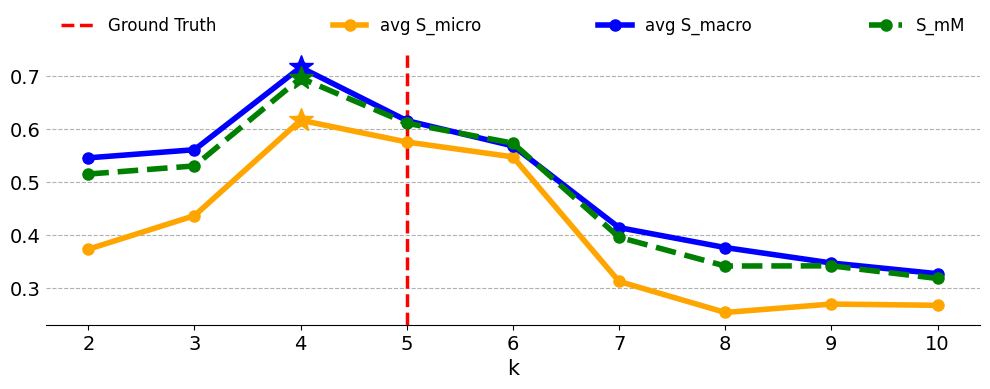

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ma


 K selected by S_mM: 4  | value at the ground-truth k:  0.6108975614518523

 K selected by subsample-average S_micro: 4  | value at the ground-truth k:  0.5754803180780206

 K selected by subsample-average S_macro: 4  |  value at the ground-truth k:  0.61579440311311

 K selected by mean (full-run) S_micro: 5  | value at the ground-truth k:  0.8070490140451364

 K selected by mean (full-run) S_macro: 5  | value at the ground-truth k:  0.8206096537132744

 K selected by mean (full-run) CH: 5  | value at the ground-truth k:  229660.44300595197

 K selected by mean (full-run) DB: 5  | value at the ground-truth k:  0.29817004018517396


In [ ]:
# Fit Composite Silhouette to S1
compsilhouette_s1 = CompSil(
    data=s1,
    k_values=range(2, 11),
    ground_truth=k_s1,
    num_samples=10,
    sample_size="auto",
    random_state=42)

# Evaluate for all candidate numbers of clusters
compsilhouette_s1.evaluate()

# get results dataframe
df_s1 = compsilhouette_s1.get_results_dataframe()
display(df_s1)

# Plot trends vs. k
compsilhouette_s1.plot_results()

# Store k selected by S_mM, subsample avg S_m, subsample avg S_M and
# each method's value at the ground-truth number of clusters
smm_k_s1, smm_val_s1 = argmax_k_and_value_at_gt(df_s1, "S_mM", k_s1)
subavg_micro_k_s1, subavg_micro_val_s1 = argmax_k_and_value_at_gt(df_s1, "avg S_micro", k_s1)
subavg_macro_k_s1, subavg_macro_val_s1 = argmax_k_and_value_at_gt(df_s1, "avg S_macro", k_s1)

# Store k selected by average S_m, average S_M, average CH, average DB and
# each method's value at the ground-truth number of clusters
full_out_s1 = mean_metrics_over_runs_choose_k(X=s1,
                                              num_runs=10,
                                              k_values=range(2, 11),
                                              random_state=42,
                                              kmeans_n_init=1,
                                              k_true=k_s1)

avg_micro_k_s1 = full_out_s1["k_micro"]
avg_micro_val_s1 = full_out_s1["mean_micro_at_k_micro"]

avg_macro_k_s1 = full_out_s1["k_macro"]
avg_macro_val_s1 = full_out_s1["mean_macro_at_k_macro"]

avg_ch_k_s1 = full_out_s1["k_ch"]
avg_ch_val_s1 = full_out_s1["mean_ch_at_k_ch"]

avg_db_k_s1 = full_out_s1["k_db"]
avg_db_val_s1 = full_out_s1["mean_db_at_k_db"]

# Print selected number of clusters (k) by each method and
# each method's value at the ground-truth number of clusters
print("\n K selected by S_mM:", smm_k_s1," | value at the ground-truth k: ",smm_val_s1)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_s1," | value at the ground-truth k: ",subavg_micro_val_s1)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_s1," |  value at the ground-truth k: ",subavg_macro_val_s1)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_s1, " | value at the ground-truth k: ", avg_micro_val_s1)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_s1, " | value at the ground-truth k: ", avg_macro_val_s1)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_s1,    " | value at the ground-truth k: ", avg_ch_val_s1)
print("\n K selected by mean (full-run) DB:",      avg_db_k_s1,    " | value at the ground-truth k: ", avg_db_val_s1)

results_main[name_s1] = {
    "k_true": k_s1, # ground-truth k (number of clusters)

    "k_SmM": smm_k_s1, # k that corresponds to the highest composite silhouette S_mM value
    "SmM": smm_val_s1, # composite silhouette S_mM value at ground-truth k

    "k_subavg_micro": subavg_micro_k_s1, # k that corresponds to the highest subsample-average S_micro value
    "subavg_micro": subavg_micro_val_s1, # subsample-average S_micro value at ground-truth k

    "k_subavg_macro": subavg_macro_k_s1, # k that corresponds to the highest subsample-average S_macro value
    "subavg_macro": subavg_macro_val_s1, # subsample-average S_macro value at ground-truth k

    "k_avg_micro": avg_micro_k_s1, # k that corresponds to the highest mean (full-run) S_micro value
    "avg_micro": avg_micro_val_s1, # mean (full-run) S_micro value at ground-truth k

    "k_avg_macro": avg_macro_k_s1, # k that corresponds to the highest mean (full-run) S_macro value
    "avg_macro": avg_macro_val_s1, # mean (full-run) S_macro value at ground-truth k

    "k_avg_CH": avg_ch_k_s1, # k that corresponds to the highest mean CH value
    "avg_CH": avg_ch_val_s1, # mean CH value at ground-truth k

    "k_avg_DB": avg_db_k_s1,   # k that corresponds to the lowest mean DB value
    "avg_DB": avg_db_val_s1,   # mean DB value at ground-truth k
}

### S2

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.472775,0.540725,0.325930,0.531504,0.093274,0.029496,0.502008,10,6000,0.6
3,0.405540,0.562726,0.243839,0.532035,0.098469,0.031139,0.500897,10,6000,0.6
4,0.421201,0.569784,0.246730,0.539232,0.111213,0.035169,0.504063,10,6000,0.6
5,0.483833,0.578825,0.205339,0.564240,0.058980,0.018651,0.545589,10,6000,0.6
6,0.659976,0.677047,0.425480,0.674885,0.036520,0.011549,0.663336,10,6000,0.6
7,0.611223,0.580050,0.788517,0.609232,0.042998,0.013597,0.595634,10,6000,0.6
8,0.534467,0.493864,0.774348,0.532682,0.050039,0.015824,0.516859,10,6000,0.6
9,0.450578,0.430902,0.597305,0.455597,0.043815,0.013855,0.441742,10,6000,0.6
10,0.402795,0.389120,0.556504,0.404783,0.021816,0.006899,0.397884,10,6000,0.6


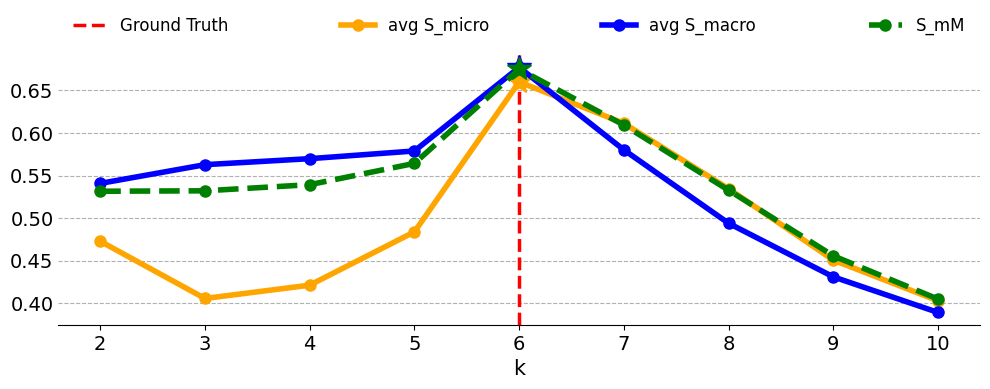

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ma


 K selected by S_mM: 6  | value at the ground-truth k:  0.6748845119205403

 K selected by subsample-average S_micro: 6  | value at the ground-truth k:  0.6599759732459953

 K selected by subsample-average S_macro: 6  | value at the ground-truth k:  0.6770474329050717

 K selected by mean (full-run) S_micro: 6  | value at the ground-truth k:  0.6922521695878949

 K selected by mean (full-run) S_macro: 6  | value at the ground-truth k:  0.6923306876452953

 K selected by mean (full-run) CH: 6  | value at the ground-truth k:  62263.98006349001

 K selected by mean (full-run) DB: 6  | value at the ground-truth k:  0.429301503803151


In [ ]:
# Fit Composite Silhouette to S2
compsilhouette_s2 = CompSil(
    data=s2,
    k_values=range(2, 11),
    ground_truth=k_s2,
    num_samples=10,
    sample_size="auto",
    random_state=42)

# Evaluate for all candidate numbers of clusters
compsilhouette_s2.evaluate()

# get results dataframe
df_s2 = compsilhouette_s2.get_results_dataframe()
display(df_s2)

# Plot trends vs. k
compsilhouette_s2.plot_results()

# Store k selected by S_mM, subsample avg S_m, subsample avg S_M and
# each method's value at the ground-truth number of clusters
smm_k_s2, smm_val_s2 = argmax_k_and_value_at_gt(df_s2, "S_mM", k_s2)
subavg_micro_k_s2, subavg_micro_val_s2 = argmax_k_and_value_at_gt(df_s2, "avg S_micro", k_s2)
subavg_macro_k_s2, subavg_macro_val_s2 = argmax_k_and_value_at_gt(df_s2, "avg S_macro", k_s2)

# Store k selected by average S_m, average S_M, average CH, average DB and
# each method's value at the ground-truth number of clusters
full_out_s2 = mean_metrics_over_runs_choose_k(X=s2, num_runs=10, k_values=range(2, 11), random_state=42, kmeans_n_init=1, k_true=k_s2)

avg_micro_k_s2 = full_out_s2["k_micro"]
avg_micro_val_s2 = full_out_s2["mean_micro_at_k_micro"]

avg_macro_k_s2 = full_out_s2["k_macro"]
avg_macro_val_s2 = full_out_s2["mean_macro_at_k_macro"]

avg_ch_k_s2 = full_out_s2["k_ch"]
avg_ch_val_s2 = full_out_s2["mean_ch_at_k_ch"]

avg_db_k_s2 = full_out_s2["k_db"]
avg_db_val_s2 = full_out_s2["mean_db_at_k_db"]

# Print selected number of clusters (k) by each method and
# each method's value at the ground-truth number of clusters
print("\n K selected by S_mM:", smm_k_s2," | value at the ground-truth k: ",smm_val_s2)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_s2," | value at the ground-truth k: ",subavg_micro_val_s2)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_s2," | value at the ground-truth k: ",subavg_macro_val_s2)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_s2, " | value at the ground-truth k: ", avg_micro_val_s2)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_s2, " | value at the ground-truth k: ", avg_macro_val_s2)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_s2,    " | value at the ground-truth k: ", avg_ch_val_s2)
print("\n K selected by mean (full-run) DB:",      avg_db_k_s2,    " | value at the ground-truth k: ", avg_db_val_s2)

results_main[name_s2] = {
    "k_true": k_s2, # ground-truth k (number of clusters)

    "k_SmM": smm_k_s2, # k that corresponds to the highest composite silhouette S_mM value
    "SmM": smm_val_s2, # composite silhouette S_mM value at ground-truth k

    "k_subavg_micro": subavg_micro_k_s2, # k that corresponds to the highest subsample-average S_micro value
    "subavg_micro": subavg_micro_val_s2, # subsample-average S_micro value at ground-truth k

    "k_subavg_macro": subavg_macro_k_s2, # k that corresponds to the highest subsample-average S_macro value
    "subavg_macro": subavg_macro_val_s2, # subsample-average S_macro value at ground-truth k

    "k_avg_micro": avg_micro_k_s2, # k that corresponds to the highest mean (full-run) S_micro value
    "avg_micro": avg_micro_val_s2, # mean (full-run) S_micro value at ground-truth k

    "k_avg_macro": avg_macro_k_s2, # k that corresponds to the highest mean (full-run) S_macro value
    "avg_macro": avg_macro_val_s2, # mean (full-run) S_macro value at ground-truth k

    "k_avg_CH": avg_ch_k_s2, # k that corresponds to the highest mean CH value
    "avg_CH": avg_ch_val_s2, # mean CH value at ground-truth k

    "k_avg_DB": avg_db_k_s2,   # k that corresponds to the lowest mean DB value
    "avg_DB": avg_db_val_s2,   # mean DB value at ground-truth k
}

### S3

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.614615,0.704300,0.320738,0.704670,0.060307,0.006031,0.698639,100,1380,0.6
3,0.422698,0.572754,0.261891,0.551691,0.167235,0.016724,0.534967,100,1380,0.6
4,0.349652,0.523567,0.243084,0.491974,0.158479,0.015848,0.476126,100,1380,0.6
5,0.275451,0.443803,0.253439,0.409493,0.119530,0.011953,0.397540,100,1380,0.6
6,0.295738,0.464140,0.230965,0.431352,0.091148,0.009115,0.422237,100,1380,0.6
7,0.285843,0.437172,0.214509,0.410409,0.088810,0.008881,0.401528,100,1380,0.6
8,0.294903,0.420180,0.229778,0.396655,0.073050,0.007305,0.389350,100,1380,0.6
9,0.303803,0.419339,0.216151,0.398260,0.061404,0.006140,0.392119,100,1380,0.6
10,0.310512,0.397624,0.262659,0.379336,0.055648,0.005565,0.373771,100,1380,0.6


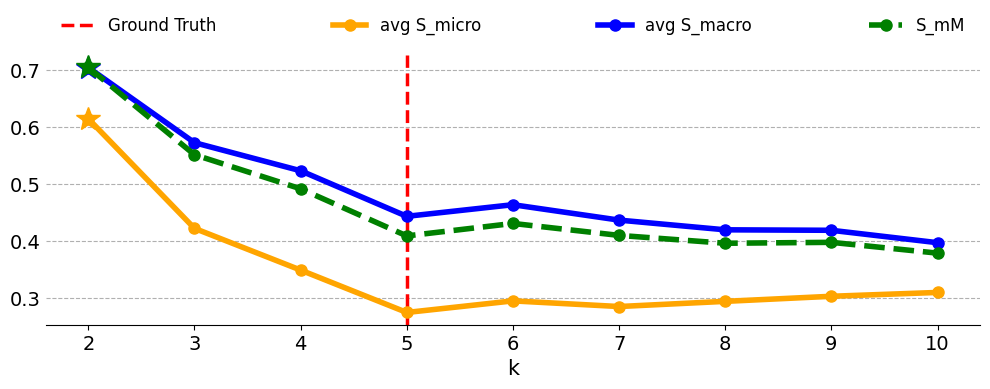

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ma


 K selected by S_mM: 2  | value at the ground-truth k:  0.40949283564689815

 K selected by subsample-average S_micro: 2  | value at the ground-truth k:  0.2754510649337946

 K selected by subsample-average S_macro: 2  | value at the ground-truth k:  0.44380342556477415

 K selected by mean (full-run) S_micro: 2  | value at the ground-truth k:  0.25067887666865385

 K selected by mean (full-run) S_macro: 3  | value at the ground-truth k:  0.4756660706373004

 K selected by mean (full-run) CH: 8  | value at the ground-truth k:  815.3176874532596

 K selected by mean (full-run) DB: 2  | value at the ground-truth k:  1.531890563790291


In [ ]:
# Fit Composite Silhouette to S3
compsilhouette_s3 = CompSil(
    data=s3,
    k_values=range(2, 11),
    ground_truth=k_s3,
    num_samples=100,
    sample_size="auto",
    random_state=42)

# Evaluate for all candidate numbers of clusters
compsilhouette_s3.evaluate()

# get results dataframe
df_s3 = compsilhouette_s3.get_results_dataframe()
display(df_s3)

# Plot trends vs. k
compsilhouette_s3.plot_results()

smm_k_s3, smm_val_s3 = argmax_k_and_value_at_gt(df_s3, "S_mM", k_s3)
subavg_micro_k_s3, subavg_micro_val_s3 = argmax_k_and_value_at_gt(df_s3, "avg S_micro", k_s3)
subavg_macro_k_s3, subavg_macro_val_s3 = argmax_k_and_value_at_gt(df_s3, "avg S_macro", k_s3)

full_out_s3 = mean_metrics_over_runs_choose_k(X=s3, num_runs=10, k_values=range(2, 11), random_state=42, kmeans_n_init=1, k_true=k_s3)

avg_micro_k_s3 = full_out_s3["k_micro"]
avg_micro_val_s3 = full_out_s3["mean_micro_at_k_micro"]

avg_macro_k_s3 = full_out_s3["k_macro"]
avg_macro_val_s3 = full_out_s3["mean_macro_at_k_macro"]

avg_ch_k_s3 = full_out_s3["k_ch"]
avg_ch_val_s3 = full_out_s3["mean_ch_at_k_ch"]

avg_db_k_s3 = full_out_s3["k_db"]
avg_db_val_s3 = full_out_s3["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_s3," | value at the ground-truth k: ",smm_val_s3)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_s3," | value at the ground-truth k: ",subavg_micro_val_s3)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_s3," | value at the ground-truth k: ",subavg_macro_val_s3)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_s3, " | value at the ground-truth k: ", avg_micro_val_s3)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_s3, " | value at the ground-truth k: ", avg_macro_val_s3)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_s3,    " | value at the ground-truth k: ", avg_ch_val_s3)
print("\n K selected by mean (full-run) DB:",      avg_db_k_s3,    " | value at the ground-truth k: ", avg_db_val_s3)

results_main[name_s3] = {
    "k_true": k_s3,

    "k_SmM": smm_k_s3,
    "SmM": smm_val_s3,

    "k_subavg_micro": subavg_micro_k_s3,
    "subavg_micro": subavg_micro_val_s3,

    "k_subavg_macro": subavg_macro_k_s3,
    "subavg_macro": subavg_macro_val_s3,

    "k_avg_micro": avg_micro_k_s3,
    "avg_micro": avg_micro_val_s3,

    "k_avg_macro": avg_macro_k_s3,
    "avg_macro": avg_macro_val_s3,

    "k_avg_CH": avg_ch_k_s3,
    "avg_CH": avg_ch_val_s3,

    "k_avg_DB": avg_db_k_s3,
    "avg_DB": avg_db_val_s3,
}

### S4

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
7,0.152654,0.386003,0.242677,0.339062,0.097570,0.021817,0.317244,20,2454,0.6
8,0.187802,0.418254,0.280379,0.366108,0.114065,0.025506,0.340603,20,2454,0.6
9,0.191112,0.399147,0.269620,0.352827,0.085665,0.019155,0.333672,20,2454,0.6
10,0.190273,0.323608,0.304254,0.291161,0.058568,0.013096,0.278065,20,2454,0.6
11,0.208515,0.332187,0.320496,0.307214,0.075241,0.016824,0.290390,20,2454,0.6
12,0.208496,0.321337,0.302925,0.293489,0.064297,0.014377,0.279112,20,2454,0.6
13,0.211580,0.344511,0.319041,0.309494,0.071831,0.016062,0.293432,20,2454,0.6
14,0.234120,0.359940,0.303879,0.328463,0.069955,0.015642,0.312821,20,2454,0.6
15,0.228763,0.335627,0.274439,0.311947,0.074234,0.016599,0.295348,20,2454,0.6


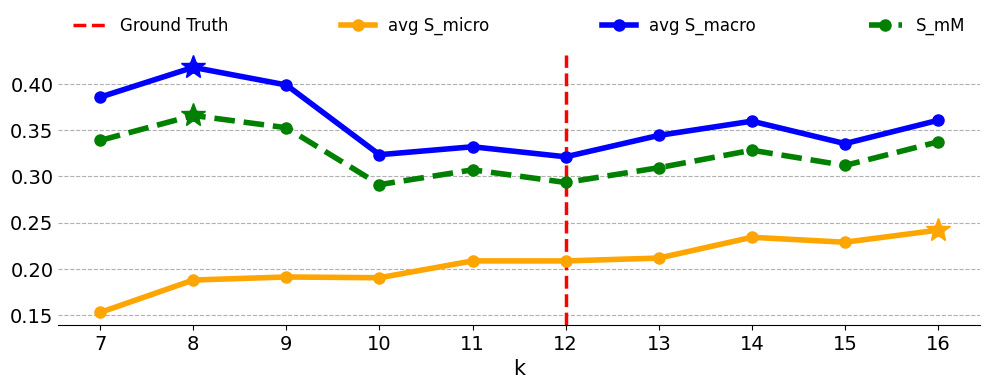

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ma


 K selected by S_mM: 8  | value at the ground-truth k:  0.29348945402939364

 K selected by subsample-average S_micro: 16  | value at the ground-truth k:  0.20849608144308213

 K selected by subsample-average S_macro: 8  | value at the ground-truth k:  0.321337010983572

 K selected by mean (full-run) S_micro: 16  | value at the ground-truth k:  0.20917653074467543

 K selected by mean (full-run) S_macro: 7  | value at the ground-truth k:  0.35644672419321527

 K selected by mean (full-run) CH: 16  | value at the ground-truth k:  288.5251129259797

 K selected by mean (full-run) DB: 9  | value at the ground-truth k:  3.947210219238226


In [ ]:
# Fit Composite Silhouette to S4
compsilhouette_s4 = CompSil(
    data=s4,
    k_values=range(7, 17),
    ground_truth=k_s4,
    num_samples=20,
    sample_size="auto",
    random_state=42)

# Evaluate for all candidate numbers of clusters
compsilhouette_s4.evaluate()

# get results dataframe
df_s4 = compsilhouette_s4.get_results_dataframe()
display(df_s4)

# Plot trends vs. k
compsilhouette_s4.plot_results()

smm_k_s4, smm_val_s4 = argmax_k_and_value_at_gt(df_s4, "S_mM", k_s4)
subavg_micro_k_s4, subavg_micro_val_s4 = argmax_k_and_value_at_gt(df_s4, "avg S_micro", k_s4)
subavg_macro_k_s4, subavg_macro_val_s4 = argmax_k_and_value_at_gt(df_s4, "avg S_macro", k_s4)

full_out_s4 = mean_metrics_over_runs_choose_k(X=s4, num_runs=20, k_values=range(7, 17), random_state=42, kmeans_n_init=1, k_true=k_s4)

avg_micro_k_s4 = full_out_s4["k_micro"]
avg_micro_val_s4 = full_out_s4["mean_micro_at_k_micro"]

avg_macro_k_s4 = full_out_s4["k_macro"]
avg_macro_val_s4 = full_out_s4["mean_macro_at_k_macro"]

avg_ch_k_s4 = full_out_s4["k_ch"]
avg_ch_val_s4 = full_out_s4["mean_ch_at_k_ch"]

avg_db_k_s4 = full_out_s4["k_db"]
avg_db_val_s4 = full_out_s4["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_s4," | value at the ground-truth k: ",smm_val_s4)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_s4," | value at the ground-truth k: ",subavg_micro_val_s4)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_s4," | value at the ground-truth k: ",subavg_macro_val_s4)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_s4, " | value at the ground-truth k: ", avg_micro_val_s4)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_s4, " | value at the ground-truth k: ", avg_macro_val_s4)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_s4,    " | value at the ground-truth k: ", avg_ch_val_s4)
print("\n K selected by mean (full-run) DB:",      avg_db_k_s4,    " | value at the ground-truth k: ", avg_db_val_s4)

results_main[name_s4] = {
    "k_true": k_s4,

    "k_SmM": smm_k_s4,
    "SmM": smm_val_s4,

    "k_subavg_micro": subavg_micro_k_s4,
    "subavg_micro": subavg_micro_val_s4,

    "k_subavg_macro": subavg_macro_k_s4,
    "subavg_macro": subavg_macro_val_s4,

    "k_avg_micro": avg_micro_k_s4,
    "avg_micro": avg_micro_val_s4,

    "k_avg_macro": avg_macro_k_s4,
    "avg_macro": avg_macro_val_s4,

    "k_avg_CH": avg_ch_k_s4,
    "avg_CH": avg_ch_val_s4,

    "k_avg_DB": avg_db_k_s4,
    "avg_DB": avg_db_val_s4,
}

### Parkinsons

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.262492,0.259693,0.809856,0.261994,2.504955e-04,4.573401e-05,0.261948,30,195,1.0
3,0.175283,0.285289,0.119394,0.272155,1.750987e-04,3.196851e-05,0.272123,30,195,1.0
4,0.151261,0.212799,0.119203,0.205463,7.252435e-17,1.324107e-17,0.205463,30,195,1.0
5,0.172183,0.252703,0.120937,0.242967,3.152391e-03,5.755453e-04,0.242392,30,195,1.0
6,0.174910,0.225352,0.135112,0.218539,2.313080e-03,4.223087e-04,0.218116,30,195,1.0
7,0.156901,0.203323,0.119203,0.197789,7.850462e-17,1.433292e-17,0.197789,30,195,1.0


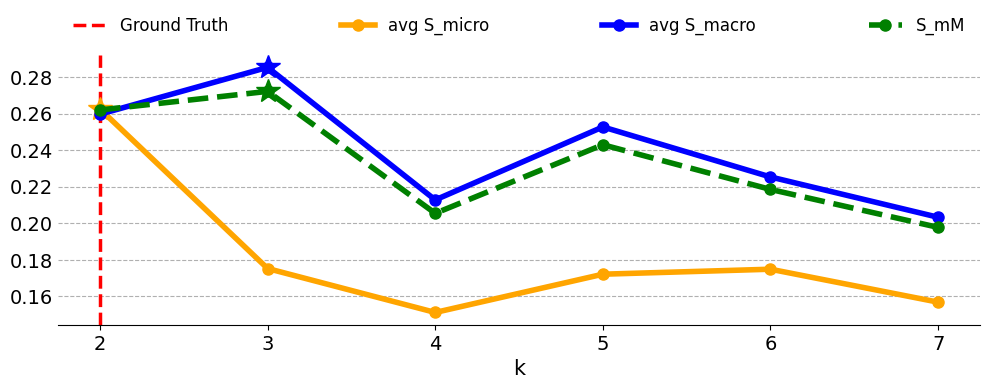


 K selected by S_mM: 3  | value at the ground-truth k:  0.26199364395352875

 K selected by subsample-average S_micro: 2  | value at the ground-truth k:  0.2624916381098845

 K selected by subsample-average S_macro: 3  | value at the ground-truth k:  0.25969337331390685

 K selected by mean (full-run) S_micro: 2  | value at the ground-truth k:  0.2623722817788355

 K selected by mean (full-run) S_macro: 3  | value at the ground-truth k:  0.259958315717845

 K selected by mean (full-run) CH: 2  | value at the ground-truth k:  81.70169629633322

 K selected by mean (full-run) DB: 3  | value at the ground-truth k:  1.3411365514158688


In [ ]:
# Fit Composite Silhouette to parkinsons
compsilhouette_park = CompSil(
    data=X_park,
    ground_truth=k_park,
    k_values=range(2, 8),
    num_samples=30,
    sample_size="auto",
    random_state=42
)

# Evaluate for all candidate numbers of clusters
compsilhouette_park.evaluate()

# get results dataframe
df_park = compsilhouette_park.get_results_dataframe()
display(df_park)

# Plot trends vs. k
compsilhouette_park.plot_results()

smm_k_park, smm_val_park = argmax_k_and_value_at_gt(df_park, "S_mM", k_park)
subavg_micro_k_park, subavg_micro_val_park = argmax_k_and_value_at_gt(df_park, "avg S_micro", k_park)
subavg_macro_k_park, subavg_macro_val_park = argmax_k_and_value_at_gt(df_park, "avg S_macro", k_park)

full_out_park = mean_metrics_over_runs_choose_k(X=X_park, num_runs=30, k_values=range(2, 8), random_state=42, kmeans_n_init=1, k_true=k_park)

avg_micro_k_park = full_out_park["k_micro"]
avg_micro_val_park = full_out_park["mean_micro_at_k_micro"]

avg_macro_k_park = full_out_park["k_macro"]
avg_macro_val_park = full_out_park["mean_macro_at_k_macro"]

avg_ch_k_park = full_out_park["k_ch"]
avg_ch_val_park = full_out_park["mean_ch_at_k_ch"]

avg_db_k_park = full_out_park["k_db"]
avg_db_val_park = full_out_park["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_park," | value at the ground-truth k: ",smm_val_park)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_park," | value at the ground-truth k: ",subavg_micro_val_park)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_park," | value at the ground-truth k: ",subavg_macro_val_park)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_park, " | value at the ground-truth k: ", avg_micro_val_park)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_park, " | value at the ground-truth k: ", avg_macro_val_park)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_park,    " | value at the ground-truth k: ", avg_ch_val_park)
print("\n K selected by mean (full-run) DB:",      avg_db_k_park,    " | value at the ground-truth k: ", avg_db_val_park)

results_main[name_park] = {
    "k_true": k_park,

    "k_SmM": smm_k_park,
    "SmM": smm_val_park,

    "k_subavg_micro": subavg_micro_k_park,
    "subavg_micro": subavg_micro_val_park,

    "k_subavg_macro": subavg_macro_k_park,
    "subavg_macro": subavg_macro_val_park,

    "k_avg_micro": avg_micro_k_park,
    "avg_micro": avg_micro_val_park,

    "k_avg_macro": avg_macro_k_park,
    "avg_macro": avg_macro_val_park,

    "k_avg_CH": avg_ch_k_park,
    "avg_CH": avg_ch_val_park,

    "k_avg_DB": avg_db_k_park,
    "avg_DB": avg_db_val_park,
}

### Blood Transfusion

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.021548,0.441965,0.182955,0.370021,0.023543,0.003329,0.366692,50,598,0.799465
3,0.042130,0.442009,0.262907,0.342287,0.081524,0.011529,0.330758,50,598,0.799465
4,0.083151,0.469509,0.245801,0.381542,0.073740,0.010428,0.371113,50,598,0.799465
5,0.102905,0.447793,0.233756,0.373415,0.058112,0.008218,0.365197,50,598,0.799465
6,0.124365,0.438411,0.218307,0.373858,0.048204,0.006817,0.367041,50,598,0.799465
7,0.134294,0.441703,0.214971,0.377931,0.039902,0.005643,0.372288,50,598,0.799465


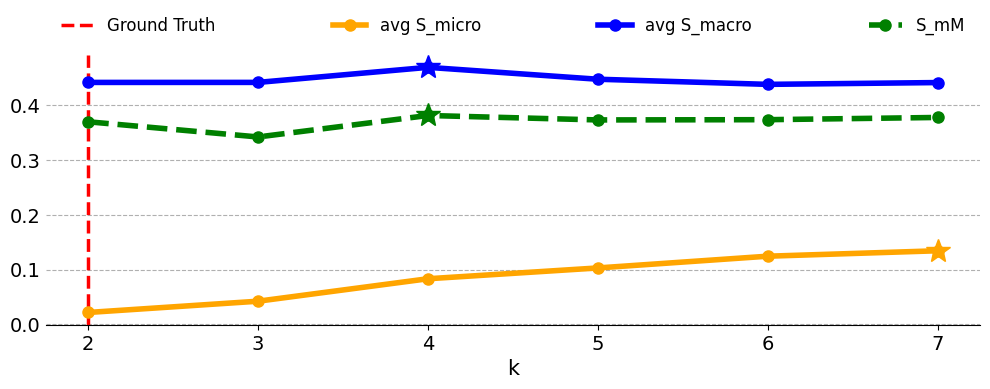

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ma


 K selected by S_mM: 4  | value at the ground-truth k:  0.3700211813350092

 K selected by subsample-average S_micro: 7  | value at the ground-truth k:  0.02154808063703348

 K selected by subsample-average S_macro: 4  | value at the ground-truth k:  0.4419645572476207

 K selected by mean (full-run) S_micro: 7  | value at the ground-truth k:  -0.11117377606302865

 K selected by mean (full-run) S_macro: 4  | value at the ground-truth k:  0.4139350096841228

 K selected by mean (full-run) CH: 6  | value at the ground-truth k:  19.486682667446857

 K selected by mean (full-run) DB: 7  | value at the ground-truth k:  1.0587892484704917


In [ ]:
# Fit Composite Silhouette to Blood Transfusion
compsilhouette_blood = CompSil(
    data=X_blood,
    ground_truth=k_blood,
    k_values=range(2, 8),
    num_samples=50,
    sample_size="auto",
    random_state=42
)

# Evaluate for all candidate numbers of clusters
compsilhouette_blood.evaluate()

# get results dataframe
df_blood = compsilhouette_blood.get_results_dataframe()
display(df_blood)

# Plot trends vs. k
compsilhouette_blood.plot_results()

smm_k_blood, smm_val_blood = argmax_k_and_value_at_gt(df_blood, "S_mM", k_blood)
subavg_micro_k_blood, subavg_micro_val_blood = argmax_k_and_value_at_gt(df_blood, "avg S_micro", k_blood)
subavg_macro_k_blood, subavg_macro_val_blood = argmax_k_and_value_at_gt(df_blood, "avg S_macro", k_blood)

full_out_blood = mean_metrics_over_runs_choose_k(X=X_blood, num_runs=50, k_values=range(2, 8), random_state=42, kmeans_n_init=1, k_true=k_blood)

avg_micro_k_blood = full_out_blood["k_micro"]
avg_micro_val_blood = full_out_blood["mean_micro_at_k_micro"]

avg_macro_k_blood = full_out_blood["k_macro"]
avg_macro_val_blood = full_out_blood["mean_macro_at_k_macro"]

avg_ch_k_blood = full_out_blood["k_ch"]
avg_ch_val_blood = full_out_blood["mean_ch_at_k_ch"]

avg_db_k_blood = full_out_blood["k_db"]
avg_db_val_blood = full_out_blood["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_blood," | value at the ground-truth k: ",smm_val_blood)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_blood," | value at the ground-truth k: ",subavg_micro_val_blood)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_blood," | value at the ground-truth k: ",subavg_macro_val_blood)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_blood, " | value at the ground-truth k: ", avg_micro_val_blood)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_blood, " | value at the ground-truth k: ", avg_macro_val_blood)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_blood,    " | value at the ground-truth k: ", avg_ch_val_blood)
print("\n K selected by mean (full-run) DB:",      avg_db_k_blood,    " | value at the ground-truth k: ", avg_db_val_blood)

results_main[name_blood] = {
    "k_true": k_blood,

    "k_SmM": smm_k_blood,
    "SmM": smm_val_blood,

    "k_subavg_micro": subavg_micro_k_blood,
    "subavg_micro": subavg_micro_val_blood,

    "k_subavg_macro": subavg_macro_k_blood,
    "subavg_macro": subavg_macro_val_blood,

    "k_avg_micro": avg_micro_k_blood,
    "avg_micro": avg_micro_val_blood,

    "k_avg_macro": avg_macro_k_blood,
    "avg_macro": avg_macro_val_blood,

    "k_avg_CH": avg_ch_k_blood,
    "avg_CH": avg_ch_val_blood,

    "k_avg_DB": avg_db_k_blood,
    "avg_DB": avg_db_val_blood,
}

### HTRU2

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.600771,0.401007,0.877089,0.576221,0.005393,0.000985,0.575236,30,10738,0.599955
3,0.408570,0.368507,0.679142,0.408890,0.049932,0.009116,0.399773,30,10738,0.599955
4,0.405195,0.381772,0.714016,0.399480,0.014039,0.002563,0.396917,30,10738,0.599955
5,0.302744,0.327997,0.222419,0.322613,0.004805,0.000877,0.321736,30,10738,0.599955
6,0.264054,0.310437,0.169874,0.302677,0.005223,0.000954,0.301724,30,10738,0.599955
7,0.264460,0.302291,0.160184,0.296334,0.005077,0.000927,0.295407,30,10738,0.599955


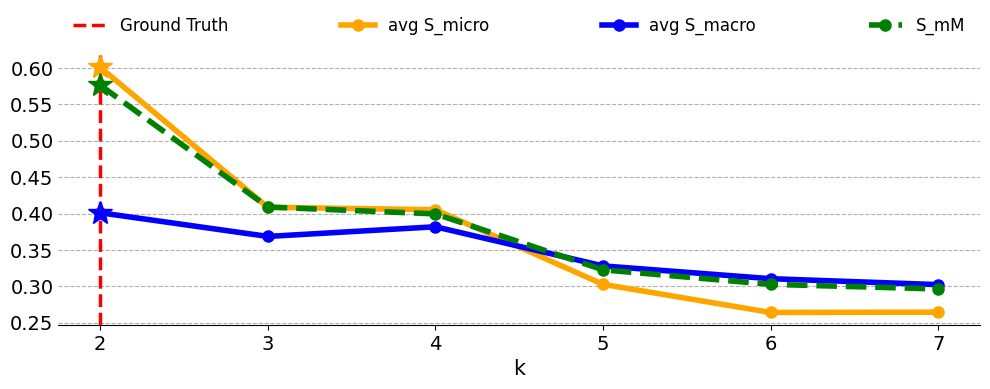


 K selected by S_mM: 2  | value at the ground-truth k:  0.5762208608764666

 K selected by subsample-average S_micro: 2  | value at the ground-truth k:  0.6007708385608007

 K selected by subsample-average S_macro: 2  | value at the ground-truth k:  0.40100675720574386

 K selected by mean (full-run) S_micro: 2  | value at the ground-truth k:  0.6032887627805786

 K selected by mean (full-run) S_macro: 2  | value at the ground-truth k:  0.40376486676193013

 K selected by mean (full-run) CH: 2  | value at the ground-truth k:  9802.409068099569

 K selected by mean (full-run) DB: 4  | value at the ground-truth k:  1.0680651916634638


In [ ]:
# Fit Composite Silhouette to HTRU2
compsilhouette_htr = CompSil(
    data=X_htr,
    ground_truth=k_htr,
    k_values=range(2, 8),
    num_samples=30,
    sample_size="auto",
    random_state=42
)

# Evaluate for all candidate numbers of clusters
compsilhouette_htr.evaluate()

# get results dataframe
df_htr = compsilhouette_htr.get_results_dataframe()
display(df_htr)

# Plot trends vs. k
compsilhouette_htr.plot_results()

smm_k_htr, smm_val_htr = argmax_k_and_value_at_gt(df_htr, "S_mM", k_htr)
subavg_micro_k_htr, subavg_micro_val_htr = argmax_k_and_value_at_gt(df_htr, "avg S_micro", k_htr)
subavg_macro_k_htr, subavg_macro_val_htr = argmax_k_and_value_at_gt(df_htr, "avg S_macro", k_htr)

full_out_htr = mean_metrics_over_runs_choose_k(X=X_htr, num_runs=30, k_values=range(2, 8), random_state=42, kmeans_n_init=1, k_true=k_htr)

avg_micro_k_htr = full_out_htr["k_micro"]
avg_micro_val_htr = full_out_htr["mean_micro_at_k_micro"]

avg_macro_k_htr = full_out_htr["k_macro"]
avg_macro_val_htr = full_out_htr["mean_macro_at_k_macro"]

avg_ch_k_htr = full_out_htr["k_ch"]
avg_ch_val_htr = full_out_htr["mean_ch_at_k_ch"]

avg_db_k_htr = full_out_htr["k_db"]
avg_db_val_htr = full_out_htr["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_htr," | value at the ground-truth k: ",smm_val_htr)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_htr," | value at the ground-truth k: ",subavg_micro_val_htr)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_htr," | value at the ground-truth k: ",subavg_macro_val_htr)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_htr, " | value at the ground-truth k: ", avg_micro_val_htr)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_htr, " | value at the ground-truth k: ", avg_macro_val_htr)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_htr,    " | value at the ground-truth k: ", avg_ch_val_htr)
print("\n K selected by mean (full-run) DB:",      avg_db_k_htr,    " | value at the ground-truth k: ", avg_db_val_htr)

results_main[name_htr] = {
    "k_true": k_htr,

    "k_SmM": smm_k_htr,
    "SmM": smm_val_htr,

    "k_subavg_micro": subavg_micro_k_htr,
    "subavg_micro": subavg_micro_val_htr,

    "k_subavg_macro": subavg_macro_k_htr,
    "subavg_macro": subavg_macro_val_htr,

    "k_avg_micro": avg_micro_k_htr,
    "avg_micro": avg_micro_val_htr,

    "k_avg_macro": avg_macro_k_htr,
    "avg_macro": avg_macro_val_htr,

    "k_avg_CH": avg_ch_k_htr,
    "avg_CH": avg_ch_val_htr,

    "k_avg_DB": avg_db_k_htr,
    "avg_DB": avg_db_val_htr,
}

### Spambase

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.151885,0.513040,0.266575,0.436491,0.146867,0.026814,0.409677,30,2760,0.59987
3,0.012684,0.605989,0.211809,0.486756,0.075324,0.013752,0.473004,30,2760,0.59987
4,-0.102753,0.616191,0.189581,0.487901,0.077647,0.014176,0.473725,30,2760,0.59987
5,-0.133829,0.605281,0.188460,0.473140,0.081201,0.014825,0.458314,30,2760,0.59987
6,-0.219217,0.581506,0.168573,0.451476,0.086253,0.015748,0.435729,30,2760,0.59987
7,-0.257792,0.567114,0.154873,0.441981,0.070968,0.012957,0.429024,30,2760,0.59987


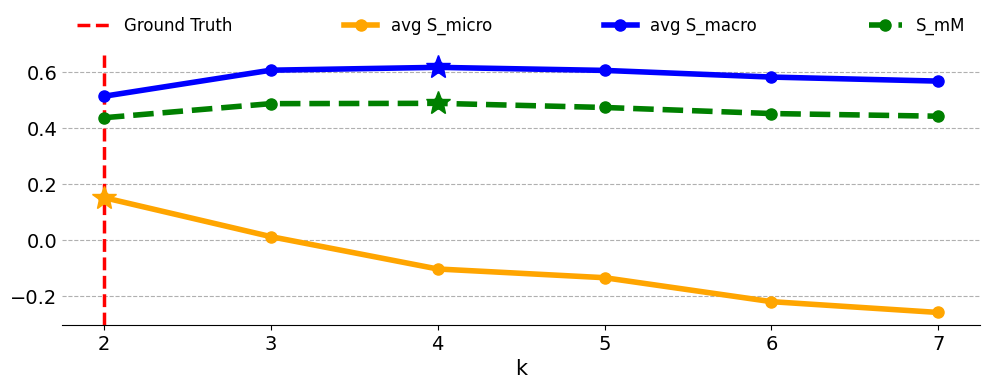

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ma


 K selected by S_mM: 4  | value at the ground-truth k:  0.43649144952116853

 K selected by subsample-average S_micro: 2  | value at the ground-truth k:  0.15188512958250697

 K selected by subsample-average S_macro: 4  | value at the ground-truth k:  0.5130404066815445

 K selected by mean (full-run) S_micro: 2  | value at the ground-truth k:  0.2677550990532752

 K selected by mean (full-run) S_macro: 6  | value at the ground-truth k:  0.43275958170418266

 K selected by mean (full-run) CH: 7  | value at the ground-truth k:  36.23861023190918

 K selected by mean (full-run) DB: 6  | value at the ground-truth k:  1.4808128341884443


In [ ]:
# Fit Composite Silhouette to Spambase
compsilhouette_spam = CompSil(
    data=X_spam,
    ground_truth=k_spam,
    k_values=range(2, 8),
    num_samples=30,
    sample_size="auto",
    random_state=42
)

# Evaluate for all candidate numbers of clusters
compsilhouette_spam.evaluate()

# get results dataframe
df_spam = compsilhouette_spam.get_results_dataframe()
display(df_spam)

# Plot trends vs. k
compsilhouette_spam.plot_results()

smm_k_spam, smm_val_spam = argmax_k_and_value_at_gt(df_spam, "S_mM", k_spam)
subavg_micro_k_spam, subavg_micro_val_spam = argmax_k_and_value_at_gt(df_spam, "avg S_micro", k_spam)
subavg_macro_k_spam, subavg_macro_val_spam = argmax_k_and_value_at_gt(df_spam, "avg S_macro", k_spam)

full_out_spam = mean_metrics_over_runs_choose_k(X=X_spam, num_runs=30, k_values=range(2, 8), random_state=42, kmeans_n_init=1, k_true=k_spam)

avg_micro_k_spam = full_out_spam["k_micro"]
avg_micro_val_spam = full_out_spam["mean_micro_at_k_micro"]

avg_macro_k_spam = full_out_spam["k_macro"]
avg_macro_val_spam = full_out_spam["mean_macro_at_k_macro"]

avg_ch_k_spam = full_out_spam["k_ch"]
avg_ch_val_spam = full_out_spam["mean_ch_at_k_ch"]

avg_db_k_spam = full_out_spam["k_db"]
avg_db_val_spam = full_out_spam["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_spam," | value at the ground-truth k: ",smm_val_spam)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_spam," | value at the ground-truth k: ",subavg_micro_val_spam)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_spam," | value at the ground-truth k: ",subavg_macro_val_spam)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_spam, " | value at the ground-truth k: ", avg_micro_val_spam)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_spam, " | value at the ground-truth k: ", avg_macro_val_spam)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_spam,    " | value at the ground-truth k: ", avg_ch_val_spam)
print("\n K selected by mean (full-run) DB:",      avg_db_k_spam,    " | value at the ground-truth k: ", avg_db_val_spam)

results_main[name_spam] = {
    "k_true": k_spam,

    "k_SmM": smm_k_spam,
    "SmM": smm_val_spam,

    "k_subavg_micro": subavg_micro_k_spam,
    "subavg_micro": subavg_micro_val_spam,

    "k_subavg_macro": subavg_macro_k_spam,
    "subavg_macro": subavg_macro_val_spam,

    "k_avg_micro": avg_micro_k_spam,
    "avg_micro": avg_micro_val_spam,

    "k_avg_macro": avg_macro_k_spam,
    "avg_macro": avg_macro_val_spam,

    "k_avg_CH": avg_ch_k_spam,
    "avg_CH": avg_ch_val_spam,

    "k_avg_DB": avg_db_k_spam,
    "avg_DB": avg_db_val_spam,
}

### Wine

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.267179,0.286235,0.119203,0.283963,1.164946e-16,1.164946e-17,0.283963,100,178,1.0
3,0.282850,0.287043,0.119203,0.286544,6.312009e-17,6.312009e-18,0.286544,100,178,1.0
4,0.227858,0.210586,0.880797,0.225799,3.253135e-17,3.253135e-18,0.225799,100,178,1.0
5,0.173414,0.164416,0.880797,0.172342,6.318170e-17,6.318170e-18,0.172342,100,178,1.0
6,0.133085,0.143110,0.119203,0.141915,3.572355e-17,3.572355e-18,0.141915,100,178,1.0
7,0.117042,0.132200,0.136749,0.130140,8.737816e-04,8.737816e-05,0.130052,100,178,1.0
8,0.122661,0.137105,0.124580,0.135312,6.049467e-04,6.049467e-05,0.135252,100,178,1.0
9,0.122804,0.133640,0.300143,0.130444,3.796995e-03,3.796995e-04,0.130064,100,178,1.0
10,0.119492,0.124012,0.283393,0.122955,1.723569e-03,1.723569e-04,0.122783,100,178,1.0


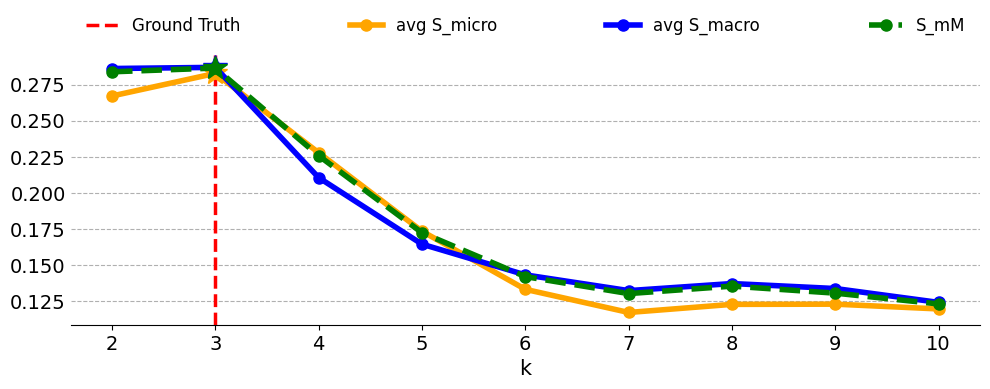


 K selected by S_mM: 3  | value at the ground-truth k:  0.28654352093859004

 K selected by subsample-average S_micro: 3  | value at the ground-truth k:  0.28284995531258533

 K selected by subsample-average S_macro: 3  | value at the ground-truth k:  0.2870433906889767

 K selected by mean (full-run) S_micro: 3  | value at the ground-truth k:  0.28284995531258533

 K selected by mean (full-run) S_macro: 3  | value at the ground-truth k:  0.2870433906889768

 K selected by mean (full-run) CH: 3  | value at the ground-truth k:  70.04106747515402

 K selected by mean (full-run) DB: 3  | value at the ground-truth k:  1.3907413947652447


In [ ]:
compsilhouette_wine = CompSil(
    data=X_wine,
    ground_truth=k_wine,
    k_values=range(2, 11),
    num_samples=100,
    sample_size="auto",
    random_state=42
)

compsilhouette_wine.evaluate()

df_wine = compsilhouette_wine.get_results_dataframe()
display(df_wine)

compsilhouette_wine.plot_results()

smm_k_wine, smm_val_wine = argmax_k_and_value_at_gt(df_wine, "S_mM", k_wine)
subavg_micro_k_wine, subavg_micro_val_wine = argmax_k_and_value_at_gt(df_wine, "avg S_micro", k_wine)
subavg_macro_k_wine, subavg_macro_val_wine = argmax_k_and_value_at_gt(df_wine, "avg S_macro", k_wine)

full_out_wine = mean_metrics_over_runs_choose_k(X=X_wine, num_runs=10, k_values=range(2, 11), random_state=42, kmeans_n_init=1, k_true=k_wine)

avg_micro_k_wine = full_out_wine["k_micro"]
avg_micro_val_wine = full_out_wine["mean_micro_at_k_micro"]

avg_macro_k_wine = full_out_wine["k_macro"]
avg_macro_val_wine = full_out_wine["mean_macro_at_k_macro"]

avg_ch_k_wine = full_out_wine["k_ch"]
avg_ch_val_wine = full_out_wine["mean_ch_at_k_ch"]

avg_db_k_wine = full_out_wine["k_db"]
avg_db_val_wine = full_out_wine["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_wine," | value at the ground-truth k: ",smm_val_wine)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_wine," | value at the ground-truth k: ",subavg_micro_val_wine)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_wine," | value at the ground-truth k: ",subavg_macro_val_wine)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_wine, " | value at the ground-truth k: ", avg_micro_val_wine)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_wine, " | value at the ground-truth k: ", avg_macro_val_wine)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_wine,    " | value at the ground-truth k: ", avg_ch_val_wine)
print("\n K selected by mean (full-run) DB:",      avg_db_k_wine,    " | value at the ground-truth k: ", avg_db_val_wine)

results_main[name_wine] = {
    "k_true": k_wine,

    "k_SmM": smm_k_wine,
    "SmM": smm_val_wine,

    "k_subavg_micro": subavg_micro_k_wine,
    "subavg_micro": subavg_micro_val_wine,

    "k_subavg_macro": subavg_macro_k_wine,
    "subavg_macro": subavg_macro_val_wine,

    "k_avg_micro": avg_micro_k_wine,
    "avg_micro": avg_micro_val_wine,

    "k_avg_macro": avg_macro_k_wine,
    "avg_macro": avg_macro_val_wine,

    "k_avg_CH": avg_ch_k_wine,
    "avg_CH": avg_ch_val_wine,

    "k_avg_DB": avg_db_k_wine,
    "avg_DB": avg_db_val_wine,
}

### Digits

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.052820,0.226123,0.126222,0.204258,0.003690,0.001167,0.203091,10,1437,0.799666
3,0.071030,0.220100,0.126162,0.201309,0.004126,0.001305,0.200004,10,1437,0.799666
4,0.085465,0.231269,0.209587,0.203403,0.028647,0.009059,0.194344,10,1437,0.799666
5,0.094885,0.232685,0.173774,0.210328,0.026956,0.008524,0.201803,10,1437,0.799666
6,0.107078,0.231882,0.158610,0.213221,0.016865,0.005333,0.207888,10,1437,0.799666
7,0.122571,0.226056,0.144770,0.212277,0.011383,0.003599,0.208678,10,1437,0.799666
8,0.144296,0.217513,0.153787,0.207538,0.008041,0.002543,0.204995,10,1437,0.799666
9,0.169208,0.209210,0.128970,0.204060,0.001646,0.000521,0.203539,10,1437,0.799666
10,0.174950,0.205927,0.141405,0.201587,0.008306,0.002627,0.198960,10,1437,0.799666


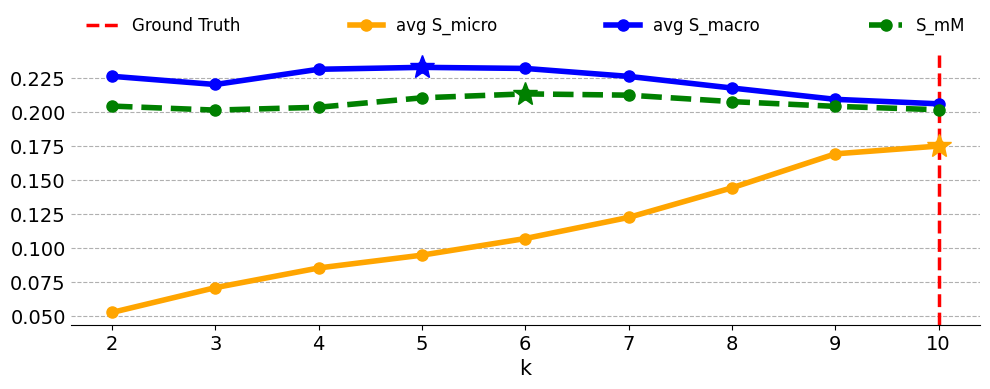


 K selected by S_mM: 6  | value at the ground-truth k:  0.20158667018664725

 K selected by subsample-average S_micro: 10  | value at the ground-truth k:  0.17495024327889389

 K selected by subsample-average S_macro: 5  | value at the ground-truth k:  0.2059267686874154

 K selected by mean (full-run) S_micro: 10  | value at the ground-truth k:  0.17997316265258317

 K selected by mean (full-run) S_macro: 4  | value at the ground-truth k:  0.21208004286611545

 K selected by mean (full-run) CH: 10  | value at the ground-truth k:  156.3214084575721

 K selected by mean (full-run) DB: 5  | value at the ground-truth k:  1.814572149880459


In [ ]:
compsilhouette_digits = CompSil(
    data=X_digits,
    ground_truth=k_digits,
    k_values=range(2, 11),
    num_samples=10,
    sample_size="auto",
    random_state=10
)

compsilhouette_digits.evaluate()

df_digits = compsilhouette_digits.get_results_dataframe()
display(df_digits)

compsilhouette_digits.plot_results()

smm_k_digits, smm_val_digits = argmax_k_and_value_at_gt(df_digits, "S_mM", k_digits)
subavg_micro_k_digits, subavg_micro_val_digits = argmax_k_and_value_at_gt(df_digits, "avg S_micro", k_digits)
subavg_macro_k_digits, subavg_macro_val_digits = argmax_k_and_value_at_gt(df_digits, "avg S_macro", k_digits)

full_out_digits = mean_metrics_over_runs_choose_k(X=X_digits, num_runs=10, k_values=range(2, 11), random_state=42, kmeans_n_init=1, k_true=k_digits)

avg_micro_k_digits = full_out_digits["k_micro"]
avg_micro_val_digits = full_out_digits["mean_micro_at_k_micro"]

avg_macro_k_digits = full_out_digits["k_macro"]
avg_macro_val_digits = full_out_digits["mean_macro_at_k_macro"]

avg_ch_k_digits = full_out_digits["k_ch"]
avg_ch_val_digits = full_out_digits["mean_ch_at_k_ch"]

avg_db_k_digits = full_out_digits["k_db"]
avg_db_val_digits = full_out_digits["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_digits," | value at the ground-truth k: ",smm_val_digits)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_digits," | value at the ground-truth k: ",subavg_micro_val_digits)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_digits," | value at the ground-truth k: ",subavg_macro_val_digits)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_digits, " | value at the ground-truth k: ", avg_micro_val_digits)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_digits, " | value at the ground-truth k: ", avg_macro_val_digits)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_digits,    " | value at the ground-truth k: ", avg_ch_val_digits)
print("\n K selected by mean (full-run) DB:",      avg_db_k_digits,    " | value at the ground-truth k: ", avg_db_val_digits)

results_main[name_digits] = {
    "k_true": k_digits,

    "k_SmM": smm_k_digits,
    "SmM": smm_val_digits,

    "k_subavg_micro": subavg_micro_k_digits,
    "subavg_micro": subavg_micro_val_digits,

    "k_subavg_macro": subavg_macro_k_digits,
    "subavg_macro": subavg_macro_val_digits,

    "k_avg_micro": avg_micro_k_digits,
    "avg_micro": avg_micro_val_digits,

    "k_avg_macro": avg_macro_k_digits,
    "avg_macro": avg_macro_val_digits,

    "k_avg_CH": avg_ch_k_digits,
    "avg_CH": avg_ch_val_digits,

    "k_avg_DB": avg_db_k_digits,
    "avg_DB": avg_db_val_digits,
}

### 20 Newsgroups

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
15,0.199313,0.420047,0.196215,0.378586,0.040448,0.009044,0.369541,20,6788,0.599965
16,0.193813,0.418922,0.196504,0.376132,0.038194,0.008540,0.367591,20,6788,0.599965
17,0.187132,0.412049,0.173260,0.374271,0.036586,0.008181,0.366090,20,6788,0.599965
18,0.180799,0.404307,0.186236,0.364108,0.028852,0.006451,0.357657,20,6788,0.599965
19,0.177959,0.393505,0.184054,0.355202,0.030215,0.006756,0.348446,20,6788,0.599965
20,0.177479,0.397687,0.174997,0.360547,0.031577,0.007061,0.353486,20,6788,0.599965
21,0.165529,0.391561,0.168951,0.354334,0.030966,0.006924,0.347410,20,6788,0.599965
22,0.168192,0.392380,0.176618,0.353701,0.029432,0.006581,0.347119,20,6788,0.599965
23,0.165451,0.391830,0.185406,0.350631,0.025860,0.005783,0.344849,20,6788,0.599965


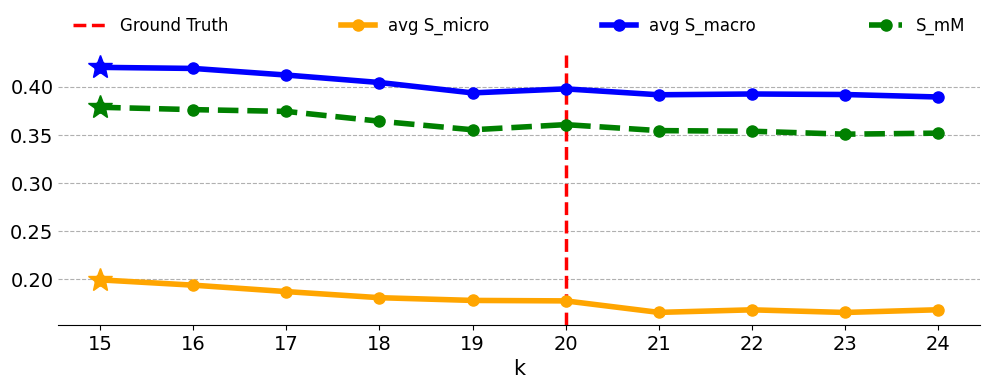

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ma


 K selected by S_mM: 15  | value at the ground-truth k:  0.36054679243229243

 K selected by subsample-average S_micro: 15  | value at the ground-truth k:  0.17747925478493284

 K selected by subsample-average S_macro: 15  | value at the ground-truth k:  0.39768694557541384

 K selected by mean (full-run) S_micro: 18  | value at the ground-truth k:  0.17650622215031087

 K selected by mean (full-run) S_macro: 15  | value at the ground-truth k:  0.4850713540572403

 K selected by mean (full-run) CH: 24  | value at the ground-truth k:  224.14384686147338

 K selected by mean (full-run) DB: 21  | value at the ground-truth k:  1.0763530679315392


In [ ]:
compsilhouette_ng = CompSil(
    data=X_ng,
    ground_truth=k_ng,
    k_values=range(15, 25),
    num_samples=20,
    sample_size="auto",
    random_state=42
)

compsilhouette_ng.evaluate()

df_ng = compsilhouette_ng.get_results_dataframe()
display(df_ng)

compsilhouette_ng.plot_results()

smm_k_ng, smm_val_ng = argmax_k_and_value_at_gt(df_ng, "S_mM", k_ng)
subavg_micro_k_ng, subavg_micro_val_ng = argmax_k_and_value_at_gt(df_ng, "avg S_micro", k_ng)
subavg_macro_k_ng, subavg_macro_val_ng = argmax_k_and_value_at_gt(df_ng, "avg S_macro", k_ng)

full_out_ng = mean_metrics_over_runs_choose_k(X=X_ng, num_runs=20, k_values=range(15, 25), random_state=42, kmeans_n_init=1, k_true=k_ng)

avg_micro_k_ng = full_out_ng["k_micro"]
avg_micro_val_ng = full_out_ng["mean_micro_at_k_micro"]

avg_macro_k_ng = full_out_ng["k_macro"]
avg_macro_val_ng = full_out_ng["mean_macro_at_k_macro"]

avg_ch_k_ng = full_out_ng["k_ch"]
avg_ch_val_ng = full_out_ng["mean_ch_at_k_ch"]

avg_db_k_ng = full_out_ng["k_db"]
avg_db_val_ng = full_out_ng["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_ng," | value at the ground-truth k: ",smm_val_ng)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_ng," | value at the ground-truth k: ",subavg_micro_val_ng)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_ng," | value at the ground-truth k: ",subavg_macro_val_ng)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_ng, " | value at the ground-truth k: ", avg_micro_val_ng)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_ng, " | value at the ground-truth k: ", avg_macro_val_ng)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_ng,    " | value at the ground-truth k: ", avg_ch_val_ng)
print("\n K selected by mean (full-run) DB:",      avg_db_k_ng,    " | value at the ground-truth k: ", avg_db_val_ng)

results_main[name_ng] = {
    "k_true": k_ng,

    "k_SmM": smm_k_ng,
    "SmM": smm_val_ng,

    "k_subavg_micro": subavg_micro_k_ng,
    "subavg_micro": subavg_micro_val_ng,

    "k_subavg_macro": subavg_macro_k_ng,
    "subavg_macro": subavg_macro_val_ng,

    "k_avg_micro": avg_micro_k_ng,
    "avg_micro": avg_micro_val_ng,

    "k_avg_macro": avg_macro_k_ng,
    "avg_macro": avg_macro_val_ng,

    "k_avg_CH": avg_ch_k_ng,
    "avg_CH": avg_ch_val_ng,

    "k_avg_DB": avg_db_k_ng,
    "avg_DB": avg_db_val_ng,
}

### STL-10

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
6,0.014910,0.027496,0.263535,0.024492,0.004208,0.001331,0.023161,10,3000,0.6
7,0.020796,0.032462,0.261616,0.029662,0.004190,0.001325,0.028337,10,3000,0.6
8,0.021590,0.036752,0.270204,0.034031,0.007048,0.002229,0.031802,10,3000,0.6
9,0.021093,0.038556,0.270301,0.034683,0.009368,0.002963,0.031721,10,3000,0.6
10,0.019666,0.042939,0.221663,0.038325,0.008784,0.002778,0.035547,10,3000,0.6
11,0.021026,0.047680,0.212267,0.042357,0.005248,0.001660,0.040698,10,3000,0.6
12,0.021658,0.051295,0.212100,0.045467,0.007075,0.002237,0.043229,10,3000,0.6
13,0.022386,0.055765,0.174148,0.050327,0.006259,0.001979,0.048348,10,3000,0.6
14,0.022806,0.058389,0.209603,0.051282,0.006965,0.002203,0.049080,10,3000,0.6


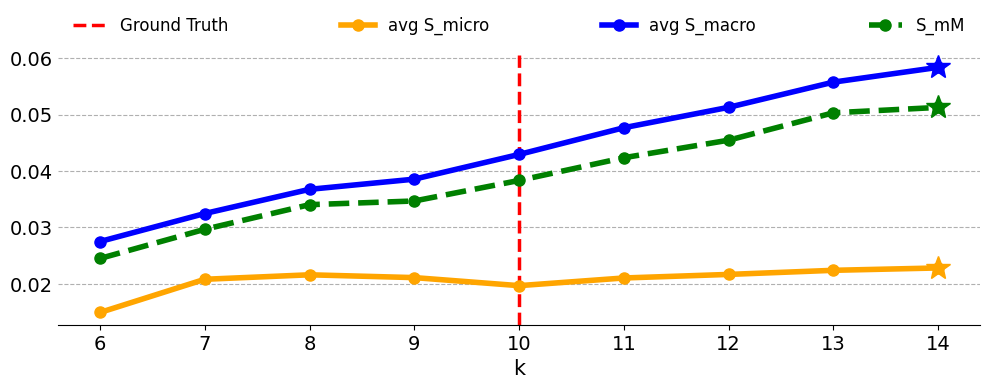


 K selected by S_mM: 14  | value at the ground-truth k:  0.03832490963890127

 K selected by subsample-average S_micro: 14  | value at the ground-truth k:  0.01966620618477464

 K selected by subsample-average S_macro: 14  | value at the ground-truth k:  0.042939244705485186

 K selected by mean (full-run) S_micro: 9  | value at the ground-truth k:  0.020886631309986116

 K selected by mean (full-run) S_macro: 14  | value at the ground-truth k:  0.041203452465124434

 K selected by mean (full-run) CH: 6  | value at the ground-truth k:  123.5406478881836

 K selected by mean (full-run) DB: 14  | value at the ground-truth k:  3.625704610980062


In [ ]:
compsilhouette_stl = CompSil(
    data=X_stl,
    ground_truth=k_stl,
    k_values=range(6, 15),
    num_samples=10,
    sample_size="auto",
    random_state=42
)

compsilhouette_stl.evaluate()

df_stl = compsilhouette_stl.get_results_dataframe()
display(df_stl)

compsilhouette_stl.plot_results()

smm_k_stl, smm_val_stl = argmax_k_and_value_at_gt(df_stl, "S_mM", k_stl)
subavg_micro_k_stl, subavg_micro_val_stl = argmax_k_and_value_at_gt(df_stl, "avg S_micro", k_stl)
subavg_macro_k_stl, subavg_macro_val_stl = argmax_k_and_value_at_gt(df_stl, "avg S_macro", k_stl)

full_out_stl = mean_metrics_over_runs_choose_k(X=X_stl, num_runs=10, k_values=range(6, 15), random_state=42, kmeans_n_init=1, k_true=k_stl)

avg_micro_k_stl = full_out_stl["k_micro"]
avg_micro_val_stl = full_out_stl["mean_micro_at_k_micro"]

avg_macro_k_stl = full_out_stl["k_macro"]
avg_macro_val_stl = full_out_stl["mean_macro_at_k_macro"]

avg_ch_k_stl = full_out_stl["k_ch"]
avg_ch_val_stl = full_out_stl["mean_ch_at_k_ch"]

avg_db_k_stl = full_out_stl["k_db"]
avg_db_val_stl = full_out_stl["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_stl," | value at the ground-truth k: ",smm_val_stl)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_stl," | value at the ground-truth k: ",subavg_micro_val_stl)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_stl," | value at the ground-truth k: ",subavg_macro_val_stl)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_stl, " | value at the ground-truth k: ", avg_micro_val_stl)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_stl, " | value at the ground-truth k: ", avg_macro_val_stl)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_stl,    " | value at the ground-truth k: ", avg_ch_val_stl)
print("\n K selected by mean (full-run) DB:",      avg_db_k_stl,    " | value at the ground-truth k: ", avg_db_val_stl)

results_main[name_stl] = {
    "k_true": k_stl,

    "k_SmM": smm_k_stl,
    "SmM": smm_val_stl,

    "k_subavg_micro": subavg_micro_k_stl,
    "subavg_micro": subavg_micro_val_stl,

    "k_subavg_macro": subavg_macro_k_stl,
    "subavg_macro": subavg_macro_val_stl,

    "k_avg_micro": avg_micro_k_stl,
    "avg_micro": avg_micro_val_stl,

    "k_avg_macro": avg_macro_k_stl,
    "avg_macro": avg_macro_val_stl,

    "k_avg_CH": avg_ch_k_stl,
    "avg_CH": avg_ch_val_stl,

    "k_avg_DB": avg_db_k_stl,
    "avg_DB": avg_db_val_stl,
}

### BBC News

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.078586,0.113902,0.165811,0.108105,0.002557,0.000572,0.107533,20,1335,0.6
3,0.078676,0.115516,0.403970,0.106762,0.039178,0.008760,0.098001,20,1335,0.6
4,0.069133,0.119329,0.352442,0.106026,0.032396,0.007244,0.098782,20,1335,0.6
5,0.078155,0.132428,0.293392,0.121637,0.024658,0.005514,0.116123,20,1335,0.6
6,0.081208,0.149561,0.292925,0.134071,0.022807,0.005100,0.128971,20,1335,0.6
7,0.092458,0.152541,0.270112,0.139698,0.020827,0.004657,0.135041,20,1335,0.6
8,0.100550,0.151704,0.200695,0.142208,0.011895,0.002660,0.139549,20,1335,0.6
9,0.099236,0.159138,0.184022,0.148757,0.011344,0.002537,0.146220,20,1335,0.6


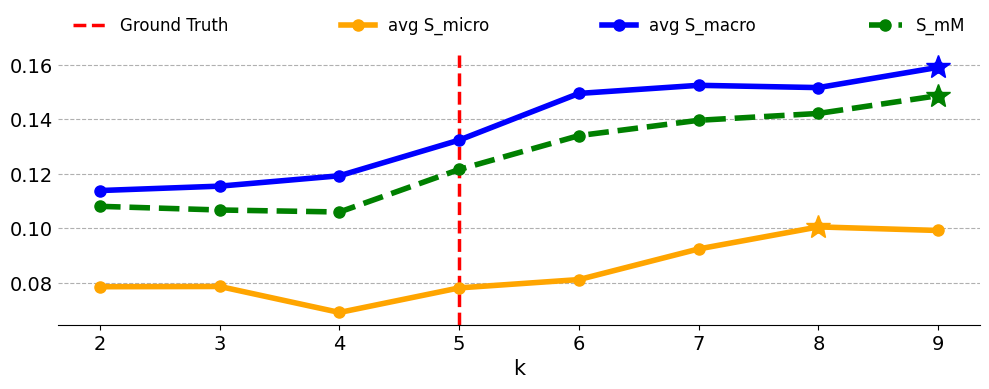


 K selected by S_mM: 9  | value at the ground-truth k:  0.12163705088585355

 K selected by subsample-average S_micro: 8  | value at the ground-truth k:  0.0781551031395793

 K selected by subsample-average S_macro: 9  | value at the ground-truth k:  0.13242815149948

 K selected by mean (full-run) S_micro: 6  | value at the ground-truth k:  0.09236749596893787

 K selected by mean (full-run) S_macro: 8  | value at the ground-truth k:  0.10985209308564663

 K selected by mean (full-run) CH: 2  | value at the ground-truth k:  147.86061477661133

 K selected by mean (full-run) DB: 8  | value at the ground-truth k:  2.675894645028244


In [ ]:
compsilhouette_bbc = CompSil(
    data=X_bbc,
    ground_truth=k_bbc,
    k_values=range(2,10),
    num_samples=20,
    sample_size="auto",
    random_state=0
)

compsilhouette_bbc.evaluate()

df_bbc = compsilhouette_bbc.get_results_dataframe()
display(df_bbc)

compsilhouette_bbc.plot_results()

smm_k_bbc, smm_val_bbc = argmax_k_and_value_at_gt(df_bbc, "S_mM", k_bbc)
subavg_micro_k_bbc, subavg_micro_val_bbc = argmax_k_and_value_at_gt(df_bbc, "avg S_micro", k_bbc)
subavg_macro_k_bbc, subavg_macro_val_bbc = argmax_k_and_value_at_gt(df_bbc, "avg S_macro", k_bbc)

full_out_bbc = mean_metrics_over_runs_choose_k(X=X_bbc, num_runs=20, k_values=range(2, 10), random_state=0, kmeans_n_init=1, k_true=k_bbc)

avg_micro_k_bbc = full_out_bbc["k_micro"]
avg_micro_val_bbc = full_out_bbc["mean_micro_at_k_micro"]

avg_macro_k_bbc = full_out_bbc["k_macro"]
avg_macro_val_bbc = full_out_bbc["mean_macro_at_k_macro"]

avg_ch_k_bbc = full_out_bbc["k_ch"]
avg_ch_val_bbc = full_out_bbc["mean_ch_at_k_ch"]

avg_db_k_bbc = full_out_bbc["k_db"]
avg_db_val_bbc = full_out_bbc["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_bbc," | value at the ground-truth k: ",smm_val_bbc)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_bbc," | value at the ground-truth k: ",subavg_micro_val_bbc)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_bbc," | value at the ground-truth k: ",subavg_macro_val_bbc)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_bbc, " | value at the ground-truth k: ", avg_micro_val_bbc)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_bbc, " | value at the ground-truth k: ", avg_macro_val_bbc)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_bbc,    " | value at the ground-truth k: ", avg_ch_val_bbc)
print("\n K selected by mean (full-run) DB:",      avg_db_k_bbc,    " | value at the ground-truth k: ", avg_db_val_bbc)

results_main[name_bbc] = {
    "k_true": k_bbc,

    "k_SmM": smm_k_bbc,
    "SmM": smm_val_bbc,

    "k_subavg_micro": subavg_micro_k_bbc,
    "subavg_micro": subavg_micro_val_bbc,

    "k_subavg_macro": subavg_macro_k_bbc,
    "subavg_macro": subavg_macro_val_bbc,

    "k_avg_micro": avg_micro_k_bbc,
    "avg_micro": avg_micro_val_bbc,

    "k_avg_macro": avg_macro_k_bbc,
    "avg_macro": avg_macro_val_bbc,

    "k_avg_CH": avg_ch_k_bbc,
    "avg_CH": avg_ch_val_bbc,

    "k_avg_DB": avg_db_k_bbc,
    "avg_DB": avg_db_val_bbc,
}

### Minds-14

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
9,0.200487,0.290424,0.119203,0.279703,6.409876e-17,2.026981e-17,0.279703,10,539,1.0
10,0.211456,0.286281,0.119203,0.277362,5.851389e-17,1.850372e-17,0.277362,10,539,1.0
11,0.226223,0.278353,0.119203,0.272139,8.275114e-17,2.616821e-17,0.272139,10,539,1.0
12,0.243735,0.285123,0.119203,0.280189,5.851389e-17,1.850372e-17,0.280189,10,539,1.0
13,0.263063,0.279987,0.119203,0.277970,6.923457e-17,2.189389e-17,0.277970,10,539,1.0
14,0.275033,0.271724,0.880797,0.274639,1.850372e-17,5.851389e-18,0.274639,10,539,1.0
15,0.271750,0.262779,0.877994,0.270658,6.083655e-05,1.923821e-05,0.270639,10,539,1.0
16,0.267666,0.256281,0.880359,0.266304,2.850966e-04,9.015545e-05,0.266213,10,539,1.0
17,0.272096,0.260690,0.880797,0.270736,5.851389e-17,1.850372e-17,0.270736,10,539,1.0


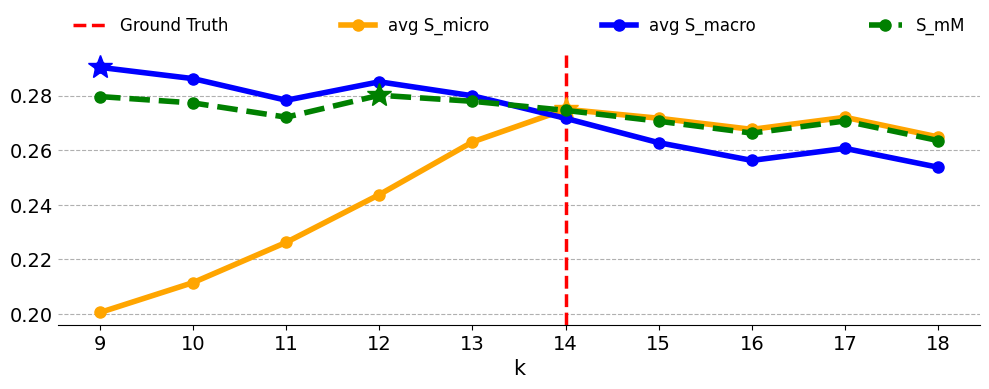


 K selected by S_mM: 12  | value at the ground-truth k:  0.2746385214962451

 K selected by subsample-average S_micro: 14  | value at the ground-truth k:  0.2750329624873076

 K selected by subsample-average S_macro: 9  | value at the ground-truth k:  0.27172397488732836

 K selected by mean (full-run) S_micro: 14  | value at the ground-truth k:  0.2750329624873076

 K selected by mean (full-run) S_macro: 9  | value at the ground-truth k:  0.27172397488732836

 K selected by mean (full-run) CH: 14  | value at the ground-truth k:  47.37740264755807

 K selected by mean (full-run) DB: 14  | value at the ground-truth k:  1.5326662177660215


In [ ]:
compsilhouette_minds = CompSil(
    data=X_minds,
    ground_truth=k_minds,
    k_values=range(9,19),
    num_samples=10,
    sample_size="auto",
    random_state=0
)

compsilhouette_minds.evaluate()
df_minds = compsilhouette_minds.get_results_dataframe()
display(df_minds)
compsilhouette_minds.plot_results()

smm_k_minds, smm_val_minds = argmax_k_and_value_at_gt(df_minds, "S_mM", k_minds)
subavg_micro_k_minds, subavg_micro_val_minds = argmax_k_and_value_at_gt(df_minds, "avg S_micro", k_minds)
subavg_macro_k_minds, subavg_macro_val_minds = argmax_k_and_value_at_gt(df_minds, "avg S_macro", k_minds)

full_out_minds = mean_metrics_over_runs_choose_k(X=X_minds, num_runs=10, k_values=range(9, 19), random_state=0, kmeans_n_init=1, k_true=k_minds)

avg_micro_k_minds = full_out_minds["k_micro"]
avg_micro_val_minds = full_out_minds["mean_micro_at_k_micro"]

avg_macro_k_minds = full_out_minds["k_macro"]
avg_macro_val_minds = full_out_minds["mean_macro_at_k_macro"]

avg_ch_k_minds = full_out_minds["k_ch"]
avg_ch_val_minds = full_out_minds["mean_ch_at_k_ch"]

avg_db_k_minds = full_out_minds["k_db"]
avg_db_val_minds = full_out_minds["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_minds," | value at the ground-truth k: ",smm_val_minds)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_minds," | value at the ground-truth k: ",subavg_micro_val_minds)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_minds," | value at the ground-truth k: ",subavg_macro_val_minds)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_minds, " | value at the ground-truth k: ", avg_micro_val_minds)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_minds, " | value at the ground-truth k: ", avg_macro_val_minds)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_minds,    " | value at the ground-truth k: ", avg_ch_val_minds)
print("\n K selected by mean (full-run) DB:",      avg_db_k_minds,    " | value at the ground-truth k: ", avg_db_val_minds)

results_main[name_minds] = {
    "k_true": k_minds,

    "k_SmM": smm_k_minds,
    "SmM": smm_val_minds,

    "k_subavg_micro": subavg_micro_k_minds,
    "subavg_micro": subavg_micro_val_minds,

    "k_subavg_macro": subavg_macro_k_minds,
    "subavg_macro": subavg_macro_val_minds,

    "k_avg_micro": avg_micro_k_minds,
    "avg_micro": avg_micro_val_minds,

    "k_avg_macro": avg_macro_k_minds,
    "avg_macro": avg_macro_val_minds,

    "k_avg_CH": avg_ch_k_minds,
    "avg_CH": avg_ch_val_minds,

    "k_avg_DB": avg_db_k_minds,
    "avg_DB": avg_db_val_minds,
}

### Banking77

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
72,0.114175,0.238427,0.149825,0.220123,0.007081,0.002239,0.217883,10,7849,0.599939
73,0.116879,0.237317,0.153621,0.219214,0.008311,0.002628,0.216586,10,7849,0.599939
74,0.116580,0.238118,0.161729,0.218911,0.008599,0.002719,0.216192,10,7849,0.599939
75,0.117866,0.238961,0.157355,0.220375,0.009554,0.003021,0.217354,10,7849,0.599939
76,0.118233,0.236642,0.151812,0.218957,0.007473,0.002363,0.216594,10,7849,0.599939
77,0.119312,0.238394,0.149270,0.220935,0.007779,0.002460,0.218475,10,7849,0.599939
78,0.123540,0.238168,0.161385,0.220064,0.009187,0.002905,0.217159,10,7849,0.599939
79,0.123080,0.236774,0.150134,0.219908,0.008135,0.002573,0.217336,10,7849,0.599939
80,0.125112,0.237556,0.158333,0.219973,0.007805,0.002468,0.217505,10,7849,0.599939


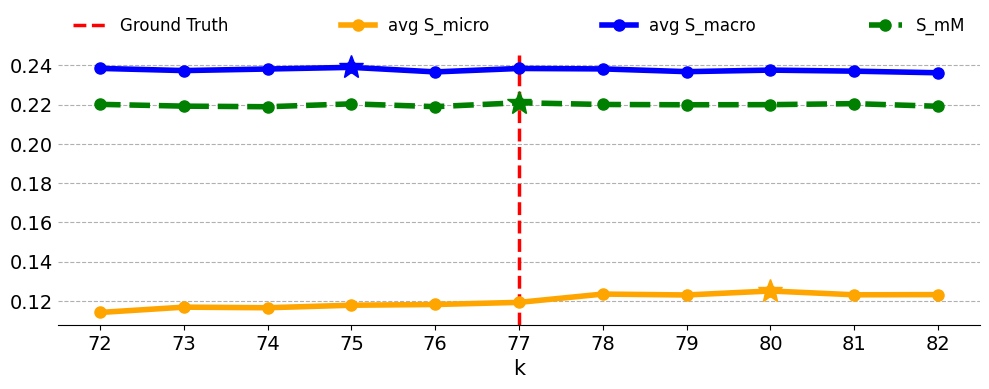

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ma


 K selected by S_mM: 77  | value at the ground-truth k:  0.2209350999120875

 K selected by subsample-average S_micro: 80  | value at the ground-truth k:  0.11931216025853257

 K selected by subsample-average S_macro: 75  | value at the ground-truth k:  0.23839423871616425

 K selected by mean (full-run) S_micro: 82  | value at the ground-truth k:  0.09815839236800102

 K selected by mean (full-run) S_macro: 79  | value at the ground-truth k:  0.24147717485555656

 K selected by mean (full-run) CH: 73  | value at the ground-truth k:  207.6723560082731

 K selected by mean (full-run) DB: 81  | value at the ground-truth k:  1.8338727337263117


In [ ]:
compsilhouette_b77 = CompSil(
    data=X_b77,
    ground_truth=k_b77,
    k_values=range(72,83),
    num_samples=10,
    sample_size="auto",
    random_state=40
)

compsilhouette_b77.evaluate()
df_b77 = compsilhouette_b77.get_results_dataframe()
display(df_b77)
compsilhouette_b77.plot_results()


smm_k_b77, smm_val_b77 = argmax_k_and_value_at_gt(df_b77, "S_mM", k_b77)
subavg_micro_k_b77, subavg_micro_val_b77 = argmax_k_and_value_at_gt(df_b77, "avg S_micro", k_b77)
subavg_macro_k_b77, subavg_macro_val_b77 = argmax_k_and_value_at_gt(df_b77, "avg S_macro", k_b77)

full_out_b77 = mean_metrics_over_runs_choose_k(X=X_b77, num_runs=10, k_values=range(72, 83), random_state=40, kmeans_n_init=1, k_true=k_b77)

avg_micro_k_b77 = full_out_b77["k_micro"]
avg_micro_val_b77 = full_out_b77["mean_micro_at_k_micro"]

avg_macro_k_b77 = full_out_b77["k_macro"]
avg_macro_val_b77 = full_out_b77["mean_macro_at_k_macro"]

avg_ch_k_b77 = full_out_b77["k_ch"]
avg_ch_val_b77 = full_out_b77["mean_ch_at_k_ch"]

avg_db_k_b77 = full_out_b77["k_db"]
avg_db_val_b77 = full_out_b77["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_b77," | value at the ground-truth k: ",smm_val_b77)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_b77," | value at the ground-truth k: ",subavg_micro_val_b77)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_b77," | value at the ground-truth k: ",subavg_macro_val_b77)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_b77, " | value at the ground-truth k: ", avg_micro_val_b77)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_b77, " | value at the ground-truth k: ", avg_macro_val_b77)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_b77,    " | value at the ground-truth k: ", avg_ch_val_b77)
print("\n K selected by mean (full-run) DB:",      avg_db_k_b77,    " | value at the ground-truth k: ", avg_db_val_b77)

results_main[name_b77] = {
    "k_true": k_b77,

    "k_SmM": smm_k_b77,
    "SmM": smm_val_b77,

    "k_subavg_micro": subavg_micro_k_b77,
    "subavg_micro": subavg_micro_val_b77,

    "k_subavg_macro": subavg_macro_k_b77,
    "subavg_macro": subavg_macro_val_b77,

    "k_avg_micro": avg_micro_k_b77,
    "avg_micro": avg_micro_val_b77,

    "k_avg_macro": avg_macro_k_b77,
    "avg_macro": avg_macro_val_b77,

    "k_avg_CH": avg_ch_k_b77,
    "avg_CH": avg_ch_val_b77,

    "k_avg_DB": avg_db_k_b77,
    "avg_DB": avg_db_val_b77,
}

### Results

In [ ]:
results_df = pd.DataFrame.from_dict(results_main, orient="index")
results_df.index.name = "dataset"
display(results_df)

,k_true,k_SmM,SmM,k_subavg_micro,subavg_micro,k_subavg_macro,subavg_macro,k_avg_micro,avg_micro,k_avg_macro,avg_macro,k_avg_CH,avg_CH,k_avg_DB,avg_DB
dataset,,,,,,,,,,,,,,,
S1,5,4,0.610898,4,0.575480,4,0.615794,5,0.807049,5,0.820610,5,229660.443006,5,0.298170
S2,6,6,0.674885,6,0.659976,6,0.677047,6,0.692252,6,0.692331,6,62263.980063,6,0.429302
S3,5,2,0.409493,2,0.275451,2,0.443803,2,0.250679,3,0.475666,8,815.317687,2,1.531891
S4,12,8,0.293489,16,0.208496,8,0.321337,16,0.209177,7,0.356447,16,288.525113,9,3.947210
Pks,2,3,0.261994,2,0.262492,3,0.259693,2,0.262372,3,0.259958,2,81.701696,3,1.341137
Bld,2,4,0.370021,7,0.021548,4,0.441965,7,-0.111174,4,0.413935,6,19.486683,7,1.058789
htr,2,2,0.576221,2,0.600771,2,0.401007,2,0.603289,2,0.403765,2,9802.409068,4,1.068065
Spm,2,4,0.436491,2,0.151885,4,0.513040,2,0.267755,6,0.432760,7,36.238610,6,1.480813
Wne,3,3,0.286544,3,0.282850,3,0.287043,3,0.282850,3,0.287043,3,70.041067,3,1.390741
